# Handwritten Digits Recognition

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import mnist 

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

Libraries imported successfully!
TensorFlow version: 2.21.0


# Load MNIST Dataset 

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Dataset loaded successfully!")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Dataset loaded successfully!


In [3]:
print("Training images shape :", X_train.shape)
print("Training labels shape :", y_train.shape)
print("Testing images shape  :", X_test.shape)
print("Testing labels shape  :", y_test.shape)

Training images shape : (60000, 28, 28)
Training labels shape : (60000,)
Testing images shape  : (10000, 28, 28)
Testing labels shape  : (10000,)


In [4]:
print("Unique classes:", np.unique(y_train))
print("Number of classes:", len(np.unique(y_train)))

Unique classes: [0 1 2 3 4 5 6 7 8 9]
Number of classes: 10


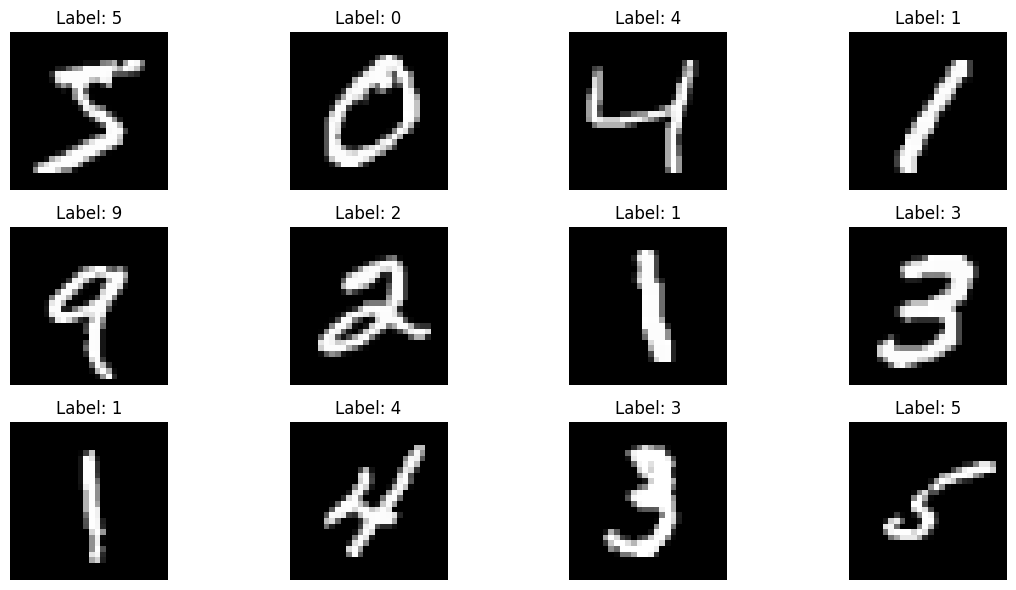

In [5]:
plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Inspect first image

print("Image shape:", X_train[0].shape)
print("Minimum pixel value:", X_train[0].min())
print("Maximum pixel value:", X_train[0].max())
print("Label:", y_train[0])

Image shape: (28, 28)
Minimum pixel value: 0
Maximum pixel value: 255
Label: 5


In [7]:
print(X_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

# Dataset Understanding & Data Analysis

In [8]:
print("Training Dataset")
print("-" * 40)
print("Number of images :", X_train.shape[0])
print("Image dimensions  :", X_train.shape[1:])
print("Number of labels  :", y_train.shape[0])

print("\nTesting Dataset")
print("-" * 40)
print("Number of images :", X_test.shape[0])
print("Image dimensions  :", X_test.shape[1:])
print("Number of labels  :", y_test.shape[0])

Training Dataset
----------------------------------------
Number of images : 60000
Image dimensions  : (28, 28)
Number of labels  : 60000

Testing Dataset
----------------------------------------
Number of images : 10000
Image dimensions  : (28, 28)
Number of labels  : 10000


In [9]:
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())
print("Mean pixel value   :", X_train.mean())
print("Standard deviation :", X_train.std())

Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value   : 33.318421449829934
Standard deviation : 78.56748998339798


In [10]:
print("X_train data type:", X_train.dtype)
print("y_train data type:", y_train.dtype)
print("X_test data type :", X_test.dtype)
print("y_test data type :", y_test.dtype)

X_train data type: uint8
y_train data type: uint8
X_test data type : uint8
y_test data type : uint8


In [12]:
print("NaN values in X_train:", np.isnan(X_train).sum())
print("NaN values in X_test :", np.isnan(X_test).sum())
print("NaN values in y_train:", np.isnan(y_train).sum())
print("NaN values in y_test :", np.isnan(y_test).sum())

NaN values in X_train: 0
NaN values in X_test : 0
NaN values in y_train: 0
NaN values in y_test : 0


In [13]:
# CLASS DISTRIBUTION

unique_classes, class_counts = np.unique(y_train, return_counts=True)

class_distribution = pd.DataFrame({
    "Digit": unique_classes,
    "Count": class_counts
})

class_distribution["Percentage"] = (class_distribution["Count"] / len(y_train) * 100)

class_distribution

,Digit,Count,Percentage
0,0,5923,9.871667
1,1,6742,11.236667
2,2,5958,9.930000
3,3,6131,10.218333
4,4,5842,9.736667
5,5,5421,9.035000
6,6,5918,9.863333
7,7,6265,10.441667
8,8,5851,9.751667
9,9,5949,9.915000


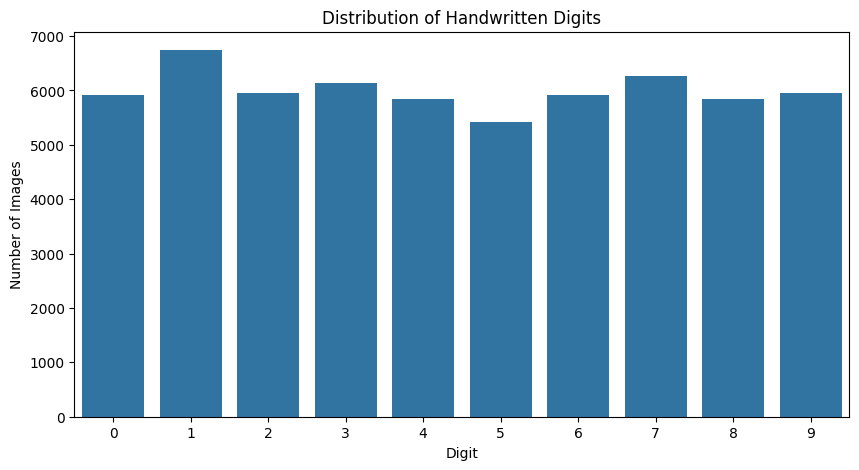

In [14]:
plt.figure(figsize=(10, 5))

sns.countplot(x=y_train)

plt.title("Distribution of Handwritten Digits")
plt.xlabel("Digit")
plt.ylabel("Number of Images")

plt.show()

In [30]:
# DUPLICATE IMAGE CHECK

In [16]:
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)

unique_images = np.unique(X_train_reshaped, axis=0)

duplicate_count = len(X_train_reshaped) - len(unique_images)

print("Total training images :", len(X_train_reshaped))
print("Unique training images:", len(unique_images))
print("Duplicate images      :", duplicate_count)

Total training images : 60000
Unique training images: 60000
Duplicate images      : 0


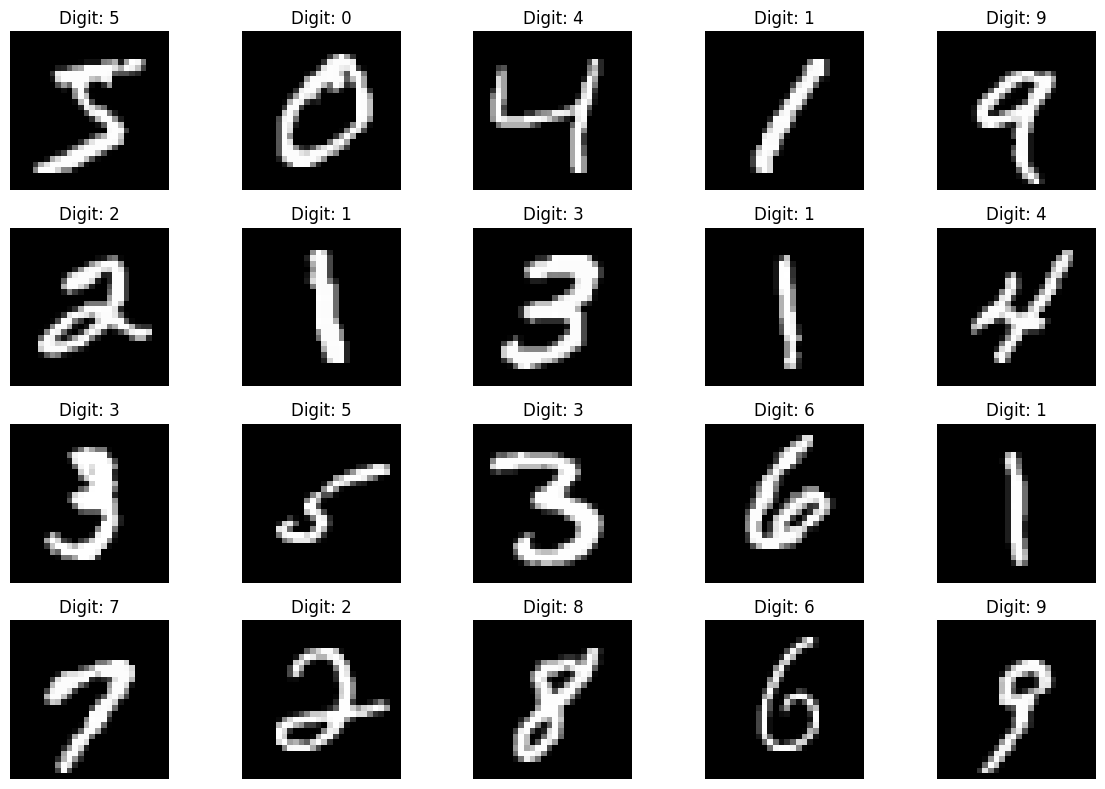

In [17]:
plt.figure(figsize=(12, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Digit: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

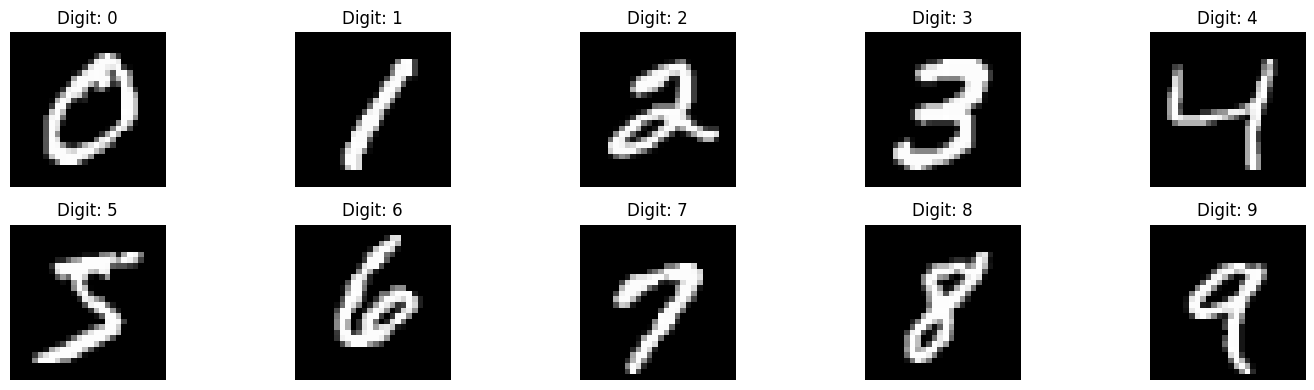

In [18]:
plt.figure(figsize=(15, 4))

for digit in range(10):
    index = np.where(y_train == digit)[0][0]

    plt.subplot(2, 5, digit + 1)
    plt.imshow(X_train[index], cmap="gray")
    plt.title(f"Digit: {digit}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
# DETAILED IMAGE ANALYSIS

In [20]:
print("Image Analysis")
print("=" * 50)

print("Image Height :", X_train.shape[1])
print("Image Width  :", X_train.shape[2])
print("Total Pixels :", X_train.shape[1] * X_train.shape[2])
print("Channels     : Grayscale (1)")

Image Analysis
Image Height : 28
Image Width  : 28
Total Pixels : 784
Channels     : Grayscale (1)


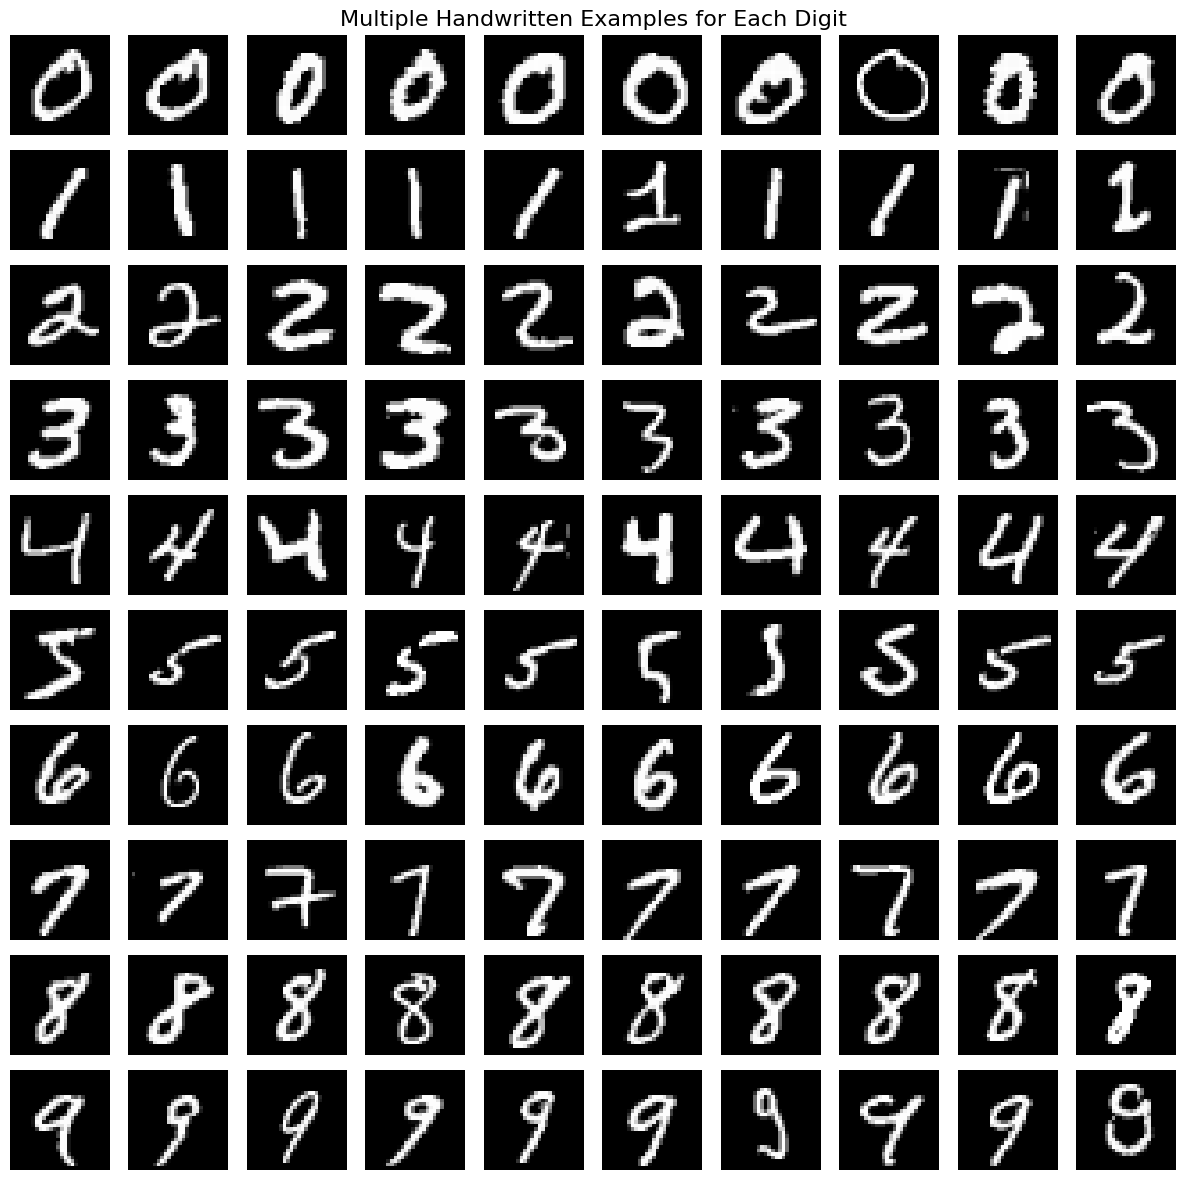

In [21]:
# Display multiple examples of each digit

fig, axes = plt.subplots(10, 10, figsize=(12, 12))

for digit in range(10):
    digit_indices = np.where(y_train == digit)[0][:10]
    
    for j, index in enumerate(digit_indices):
        axes[digit, j].imshow(X_train[index], cmap="gray")
        axes[digit, j].axis("off")
        
        if j == 0:
            axes[digit, j].set_ylabel(
                f"Digit {digit}",
                rotation=0,
                labelpad=30,
                fontsize=10
            )

plt.suptitle("Multiple Handwritten Examples for Each Digit", fontsize=16)
plt.tight_layout()
plt.show()

### Observation

The visualization shows significant variations in handwriting styles within
the same digit class. Digits may differ in shape, stroke thickness, slant,
size, and structure. Despite these variations, the images belong to the same
digit class.

This variation makes MNIST a suitable dataset for evaluating image
classification algorithms.

In [22]:
# PIXEL INTENSITY ANALYSIS

In [23]:
pixel_values = X_train.flatten()

print("Minimum Pixel Value :", pixel_values.min())
print("Maximum Pixel Value :", pixel_values.max())
print("Mean Pixel Value    :", pixel_values.mean())
print("Median Pixel Value  :", np.median(pixel_values))
print("Standard Deviation  :", pixel_values.std())

Minimum Pixel Value : 0
Maximum Pixel Value : 255
Mean Pixel Value    : 33.318421449829934
Median Pixel Value  : 0.0
Standard Deviation  : 78.56748998339798


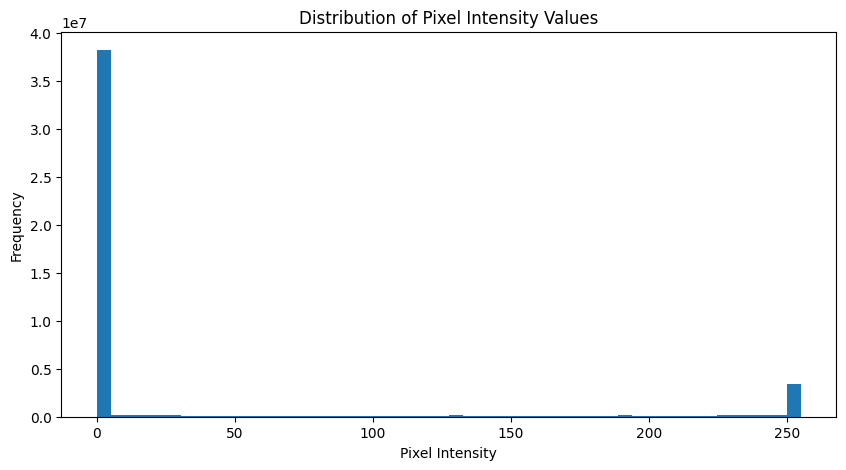

In [24]:
plt.figure(figsize=(10, 5))

plt.hist(pixel_values, bins=50)

plt.title("Distribution of Pixel Intensity Values")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

In [26]:
# BACKGROUND VS FOREGROUND PIXELS

total_pixels = X_train.size

background_pixels = np.sum(X_train == 0)
non_background_pixels = total_pixels - background_pixels

background_percentage = (background_pixels / total_pixels) * 100
non_background_percentage = (non_background_pixels / total_pixels) * 100

print("Total pixels              :", total_pixels)
print("Background pixels (0)     :", background_pixels)
print("Non-background pixels     :", non_background_pixels)

print("\nBackground percentage     :", round(background_percentage, 2), "%")
print("Non-background percentage :", round(non_background_percentage, 2), "%")

Total pixels              : 47040000
Background pixels (0)     : 38045844
Non-background pixels     : 8994156

Background percentage     : 80.88 %
Non-background percentage : 19.12 %


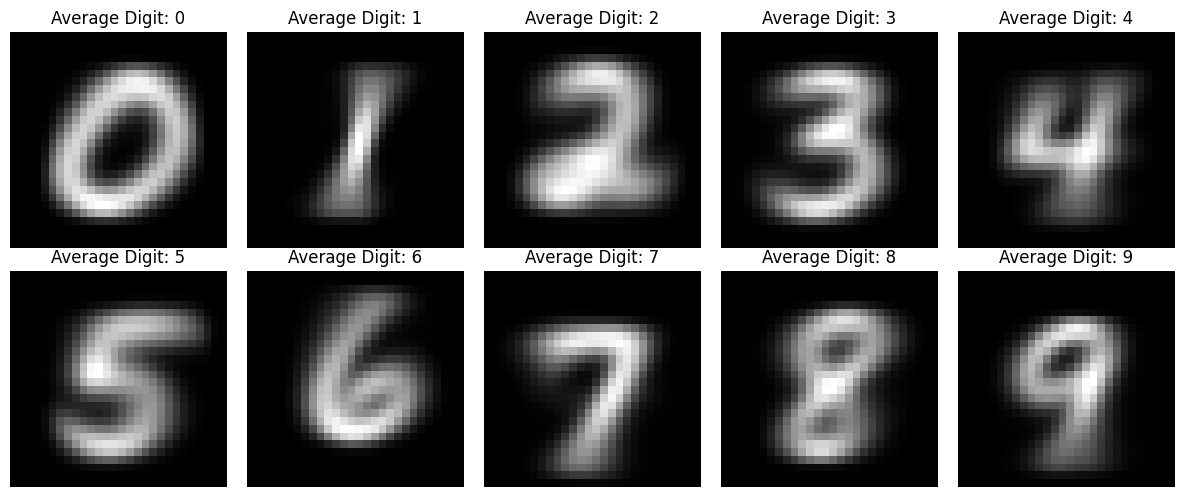

In [27]:
# AVERAGE IMAGE FOR EACH DIGIT

plt.figure(figsize=(12, 5))

for digit in range(10):
    
    # Select all images belonging to the digit
    digit_images = X_train[y_train == digit]
    
    # Calculate average image
    mean_image = digit_images.mean(axis=0)
    
    plt.subplot(2, 5, digit + 1)
    plt.imshow(mean_image, cmap="gray")
    plt.title(f"Average Digit: {digit}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
# AVERAGE PIXEL INTENSITY BY DIGIT

average_intensity = []

for digit in range(10):
    
    digit_images = X_train[y_train == digit]
    
    avg_intensity = digit_images.mean()
    
    average_intensity.append(avg_intensity)

average_intensity_df = pd.DataFrame({
    "Digit": range(10),
    "Average_Pixel_Intensity": average_intensity
})

average_intensity_df

,Digit,Average_Pixel_Intensity
0,0,44.216828
1,1,19.379654
2,2,37.988658
3,3,36.090187
4,4,30.948226
5,5,32.831095
6,6,35.011953
7,7,29.204563
8,8,38.289775
9,9,31.260435


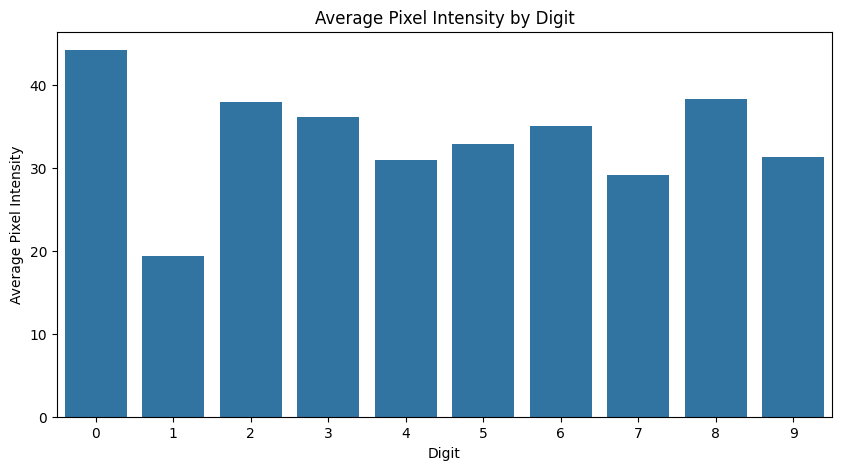

In [29]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=average_intensity_df,
    x="Digit",
    y="Average_Pixel_Intensity"
)

plt.title("Average Pixel Intensity by Digit")
plt.xlabel("Digit")
plt.ylabel("Average Pixel Intensity")

plt.show()

# Data Preprocessing

In [31]:
# STEP 4.1: PIXEL NORMALIZATION

X_train_normalized = X_train.astype("float32") / 255.0
X_test_normalized = X_test.astype("float32") / 255.0

print("Original pixel range:")
print("Minimum:", X_train.min())
print("Maximum:", X_train.max())

print("\nNormalized pixel range:")
print("Minimum:", X_train_normalized.min())
print("Maximum:", X_train_normalized.max())

Original pixel range:
Minimum: 0
Maximum: 255

Normalized pixel range:
Minimum: 0.0
Maximum: 1.0


In [32]:
print("X_train_normalized shape:", X_train_normalized.shape)
print("X_test_normalized shape :", X_test_normalized.shape)

X_train_normalized shape: (60000, 28, 28)
X_test_normalized shape : (10000, 28, 28)


In [33]:
# FLATTEN IMAGES FOR TRADITIONAL ML

X_train_flat = X_train_normalized.reshape(X_train_normalized.shape[0], -1)
X_test_flat = X_test_normalized.reshape(X_test_normalized.shape[0], -1)

print("Training data shape:", X_train_flat.shape)
print("Testing data shape :", X_test_flat.shape)

Training data shape: (60000, 784)
Testing data shape : (10000, 784)


In [34]:
# Compare original and flattened image

print("Original image shape :", X_train_normalized[0].shape)
print("Flattened image shape:", X_train_flat[0].shape)

print("\nFirst 10 flattened pixel values:")
print(X_train_flat[0][:10])

Original image shape : (28, 28)
Flattened image shape: (784,)

First 10 flattened pixel values:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


## Prepare Data for Machine Learning Models

In [35]:
# VERIFY MODELING DATA

print("Training Features :", X_train_flat.shape)
print("Testing Features  :", X_test_flat.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

print("\nNumber of Classes :", len(np.unique(y_train)))
print("Classes           :", np.unique(y_train))

Training Features : (60000, 784)
Testing Features  : (10000, 784)
Training Target   : (60000,)
Testing Target    : (10000,)

Number of Classes : 10
Classes           : [0 1 2 3 4 5 6 7 8 9]


In [36]:
from sklearn.model_selection import train_test_split

In [37]:
# CREATE VALIDATION SET

X_train_model, X_val, y_train_model, y_val = train_test_split(X_train_flat,y_train,test_size=0.10,random_state=42,stratify=y_train)

print("Training data   :", X_train_model.shape)
print("Validation data :", X_val.shape)
print("Test data       :", X_test_flat.shape)

print("\nTraining labels  :", y_train_model.shape)
print("Validation labels:", y_val.shape)
print("Test labels     :", y_test.shape)

Training data   : (54000, 784)
Validation data : (6000, 784)
Test data       : (10000, 784)

Training labels  : (54000,)
Validation labels: (6000,)
Test labels     : (10000,)


In [38]:
# CHECK CLASS DISTRIBUTION AFTER SPLIT

train_distribution = pd.Series(y_train_model).value_counts().sort_index()
val_distribution = pd.Series(y_val).value_counts().sort_index()

distribution_check = pd.DataFrame({
    "Digit": range(10),
    "Training_Count": train_distribution.values,
    "Validation_Count": val_distribution.values
})

distribution_check

,Digit,Training_Count,Validation_Count
0,0,5331,592
1,1,6068,674
2,2,5362,596
3,3,5518,613
4,4,5258,584
5,5,4879,542
6,6,5326,592
7,7,5638,627
8,8,5266,585
9,9,5354,595


In [39]:
# MODEL EVALUATION FUNCTION

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix)

def evaluate_model(model_name, y_true, y_pred):
    
    accuracy = accuracy_score(y_true, y_pred)
    
    precision = precision_score(y_true,y_pred,average="weighted",zero_division=0)
    
    recall = recall_score(y_true,y_pred,average="weighted",zero_division=0)
    
    f1 = f1_score(y_true,y_pred,average="weighted",zero_division=0)
    
    print("=" * 60)
    print(model_name)
    print("=" * 60)
    
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1
    }

In [40]:
# MODEL COMPARISON STORAGE

model_results = []

print("Model evaluation framework created successfully.")

Model evaluation framework created successfully.


# K-Nearest Neighbors Model (KNN)

In [44]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time

In [45]:
X_knn_val, _, y_knn_val, _ = train_test_split(X_val,y_val,train_size=2000,random_state=42,stratify=y_val)

print("KNN validation subset:", X_knn_val.shape)
print("KNN validation labels :", y_knn_val.shape)

KNN validation subset: (2000, 784)
KNN validation labels : (2000,)


In [46]:
k_values = [3, 5, 7, 9]

knn_validation_results = []

for k in k_values:
    
    print(f"\nTraining KNN with K = {k}")
    
    start_time = time.time()
    
    knn_model = KNeighborsClassifier(n_neighbors=k,n_jobs=-1)
    
    knn_model.fit(X_train_model, y_train_model)
    
    y_knn_pred = knn_model.predict(X_knn_val)
    
    accuracy = accuracy_score(y_knn_val, y_knn_pred)
    
    elapsed_time = time.time() - start_time
    
    knn_validation_results.append({
        "K": k,
        "Validation_Accuracy": accuracy,
        "Time_Seconds": elapsed_time
    })
    
    print(f"Validation Accuracy: {accuracy:.4f}")
    print(f"Time Taken: {elapsed_time:.2f} seconds")


Training KNN with K = 3
Validation Accuracy: 0.9720
Time Taken: 8.17 seconds

Training KNN with K = 5
Validation Accuracy: 0.9650
Time Taken: 2.57 seconds

Training KNN with K = 7
Validation Accuracy: 0.9640
Time Taken: 2.89 seconds

Training KNN with K = 9
Validation Accuracy: 0.9635
Time Taken: 2.62 seconds


In [47]:
knn_validation_df = pd.DataFrame(knn_validation_results)

knn_validation_df

,K,Validation_Accuracy,Time_Seconds
0,3,0.9720,8.172439
1,5,0.9650,2.567364
2,7,0.9640,2.886883
3,9,0.9635,2.616819


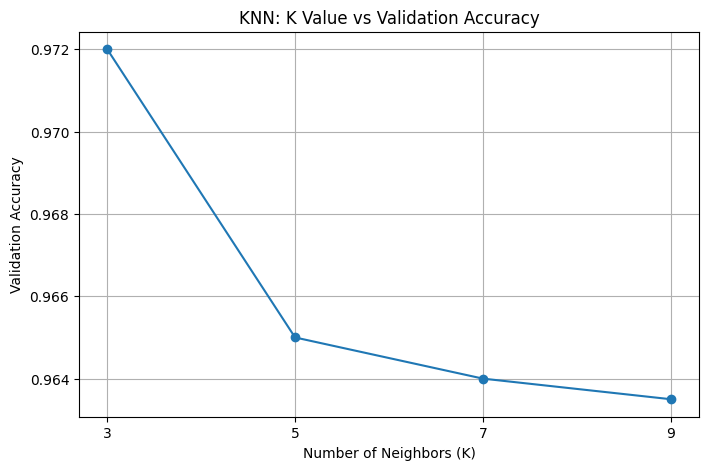

In [48]:
plt.figure(figsize=(8, 5))

plt.plot(
    knn_validation_df["K"],
    knn_validation_df["Validation_Accuracy"],
    marker="o"
)

plt.title("KNN: K Value vs Validation Accuracy")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Validation Accuracy")
plt.xticks(k_values)
plt.grid(True)

plt.show()

In [49]:
best_k = knn_validation_df.loc[knn_validation_df["Validation_Accuracy"].idxmax(),"K"]

best_knn_accuracy = knn_validation_df["Validation_Accuracy"].max()

print("Best K:", best_k)
print("Best Validation Accuracy:", round(best_knn_accuracy, 4))

Best K: 3
Best Validation Accuracy: 0.972


In [50]:
final_knn = KNeighborsClassifier(n_neighbors=int(best_k),n_jobs=-1)

print(f"Training final KNN model with K = {best_k}...")

start_time = time.time()

final_knn.fit(X_train_model, y_train_model)

knn_training_time = time.time() - start_time

print("KNN model trained successfully!")
print(f"Training time: {knn_training_time:.2f} seconds")

Training final KNN model with K = 3...
KNN model trained successfully!
Training time: 0.06 seconds


In [51]:
print("Generating predictions on test data...")

start_time = time.time()

y_knn_test_pred = final_knn.predict(X_test_flat)

knn_prediction_time = time.time() - start_time

print("Prediction completed!")
print(f"Prediction time: {knn_prediction_time:.2f} seconds")

Generating predictions on test data...
Prediction completed!
Prediction time: 10.12 seconds


In [52]:
knn_result = evaluate_model("K-Nearest Neighbors",y_test,y_knn_test_pred)

model_results.append(knn_result)

K-Nearest Neighbors
Accuracy : 0.9699
Precision: 0.9701
Recall   : 0.9699
F1 Score : 0.9699

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       980
           1       0.96      1.00      0.98      1135
           2       0.98      0.97      0.97      1032
           3       0.96      0.97      0.97      1010
           4       0.98      0.97      0.97       982
           5       0.97      0.96      0.96       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.96      1028
           8       0.99      0.94      0.96       974
           9       0.96      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



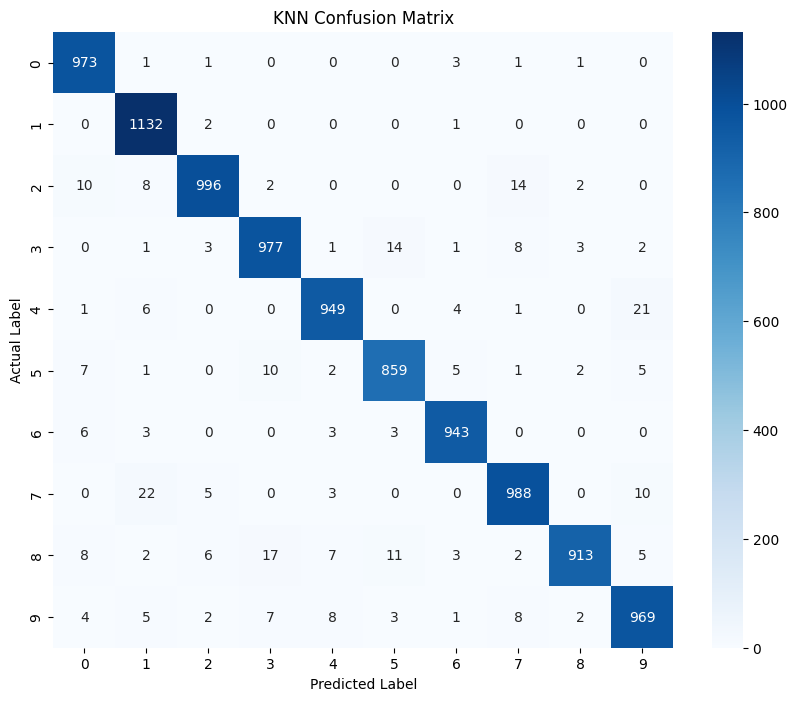

In [53]:
knn_cm = confusion_matrix(y_test, y_knn_test_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(knn_cm,annot=True,fmt="d",cmap="Blues",xticklabels=range(10),yticklabels=range(10))

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

# Support Vector Machine (SVM) Model

In [54]:
from sklearn.svm import SVC

X_svm_train, _, y_svm_train, _ = train_test_split(X_train_model,y_train_model,train_size=15000,random_state=42,stratify=y_train_model)

print("SVM training data :", X_svm_train.shape)
print("SVM training labels:", y_svm_train.shape)

SVM training data : (15000, 784)
SVM training labels: (15000,)


In [55]:
svm_model = SVC(kernel="rbf",C=10,gamma="scale")

print("Training SVM...")

start_time = time.time()

svm_model.fit(X_svm_train, y_svm_train)

svm_training_time = time.time() - start_time

print("SVM training completed!")
print(f"Training time: {svm_training_time:.2f} seconds")

Training SVM...
SVM training completed!
Training time: 29.99 seconds


In [56]:
print("Generating SVM predictions...")

start_time = time.time()

y_svm_test_pred = svm_model.predict(X_test_flat)

svm_prediction_time = time.time() - start_time

print("Prediction completed!")
print(f"Prediction time: {svm_prediction_time:.2f} seconds")

Generating SVM predictions...
Prediction completed!
Prediction time: 33.26 seconds


In [57]:
svm_result = evaluate_model("Support Vector Machine (RBF)",y_test,y_svm_test_pred)

model_results.append(svm_result)

Support Vector Machine (RBF)
Accuracy : 0.9719
Precision: 0.9719
Recall   : 0.9719
F1 Score : 0.9719

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.96      0.97      1032
           3       0.96      0.97      0.97      1010
           4       0.97      0.97      0.97       982
           5       0.98      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.97      0.97       974
           9       0.96      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



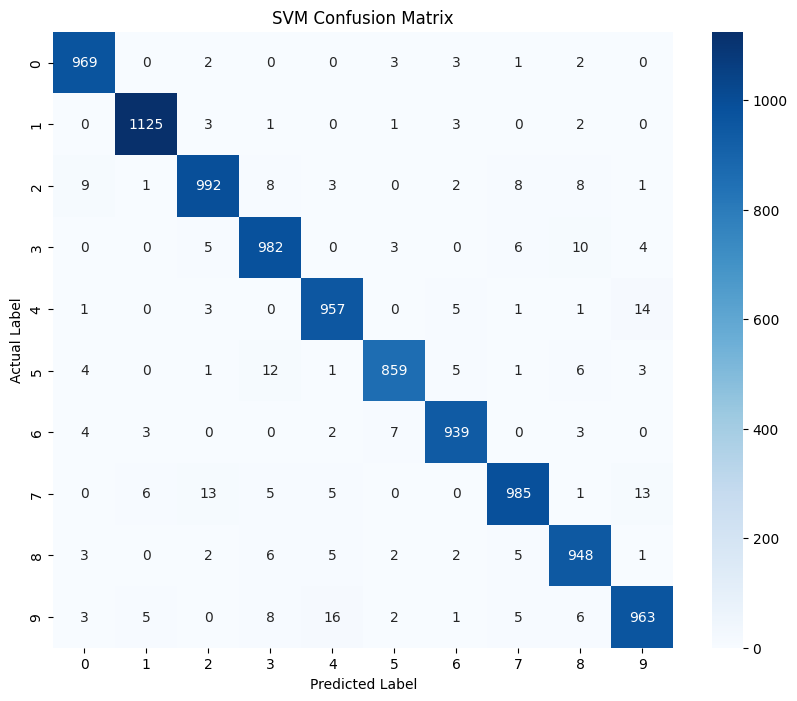

In [58]:
svm_cm = confusion_matrix(y_test, y_svm_test_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(svm_cm,annot=True,fmt="d",cmap="Blues",xticklabels=range(10),yticklabels=range(10))

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [59]:
# Logistic Regression Model

In [60]:
from sklearn.linear_model import LogisticRegression

In [61]:
logistic_model = LogisticRegression(max_iter=100,solver="lbfgs",multi_class="multinomial",n_jobs=-1,random_state=42)

print("Training Logistic Regression...")

start_time = time.time()

logistic_model.fit(X_train_model, y_train_model)

logistic_training_time = time.time() - start_time

print("Logistic Regression training completed!")
print(f"Training time: {logistic_training_time:.2f} seconds")

Training Logistic Regression...
Logistic Regression training completed!
Training time: 26.04 seconds


In [62]:
print("Generating predictions...")

start_time = time.time()

y_logistic_test_pred = logistic_model.predict(X_test_flat)

logistic_prediction_time = time.time() - start_time

print("Prediction completed!")
print(f"Prediction time: {logistic_prediction_time:.2f} seconds")

Generating predictions...
Prediction completed!
Prediction time: 0.13 seconds


In [63]:
logistic_result = evaluate_model("Logistic Regression",y_test,y_logistic_test_pred)

model_results.append(logistic_result)

Logistic Regression
Accuracy : 0.9252
Precision: 0.9251
Recall   : 0.9252
F1 Score : 0.9251

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.90      0.91      1032
           3       0.90      0.91      0.90      1010
           4       0.94      0.93      0.93       982
           5       0.90      0.87      0.89       892
           6       0.94      0.95      0.94       958
           7       0.93      0.93      0.93      1028
           8       0.87      0.88      0.88       974
           9       0.91      0.92      0.91      1009

    accuracy                           0.93     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.93      0.93      0.93     10000



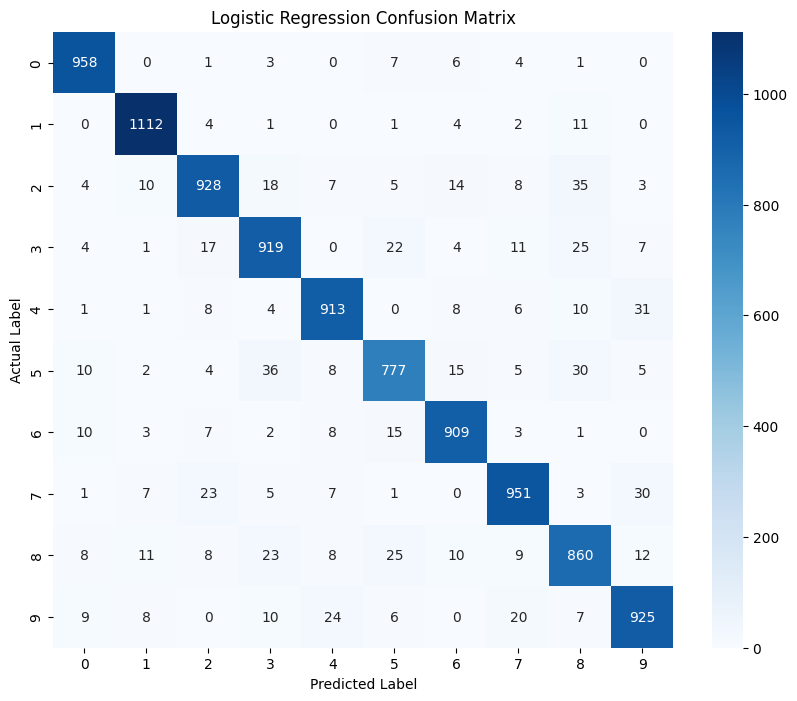

In [64]:
logistic_cm = confusion_matrix(y_test,y_logistic_test_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(logistic_cm,annot=True,fmt="d",cmap="Blues",xticklabels=range(10),yticklabels=range(10))

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [65]:
model_results_df = pd.DataFrame(model_results)

model_results_df

,Model,Accuracy,Precision,Recall,F1_Score
0,K-Nearest Neighbors,0.9699,0.970090,0.9699,0.969853
1,Support Vector Machine (RBF),0.9719,0.971923,0.9719,0.971880
2,Logistic Regression,0.9252,0.925074,0.9252,0.925051


# Random Forest Model

In [67]:
from sklearn.ensemble import RandomForestClassifier

In [68]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)

print("Training Random Forest...")

start_time = time.time()

rf_model.fit(X_train_model, y_train_model)

rf_training_time = time.time() - start_time

print("Random Forest training completed!")
print(f"Training time: {rf_training_time:.2f} seconds")

Training Random Forest...
Random Forest training completed!
Training time: 14.10 seconds


In [69]:
print("Generating Random Forest predictions...")

start_time = time.time()

y_rf_test_pred = rf_model.predict(X_test_flat)

rf_prediction_time = time.time() - start_time

print("Prediction completed!")
print(f"Prediction time: {rf_prediction_time:.2f} seconds")

Generating Random Forest predictions...
Prediction completed!
Prediction time: 0.23 seconds


In [70]:
rf_result = evaluate_model("Random Forest",y_test,y_rf_test_pred)

model_results.append(rf_result)

Random Forest
Accuracy : 0.9696
Precision: 0.9696
Recall   : 0.9696
F1 Score : 0.9696

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.96      0.96      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.97      0.96      0.97       892
           6       0.97      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.95      0.96       974
           9       0.96      0.95      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



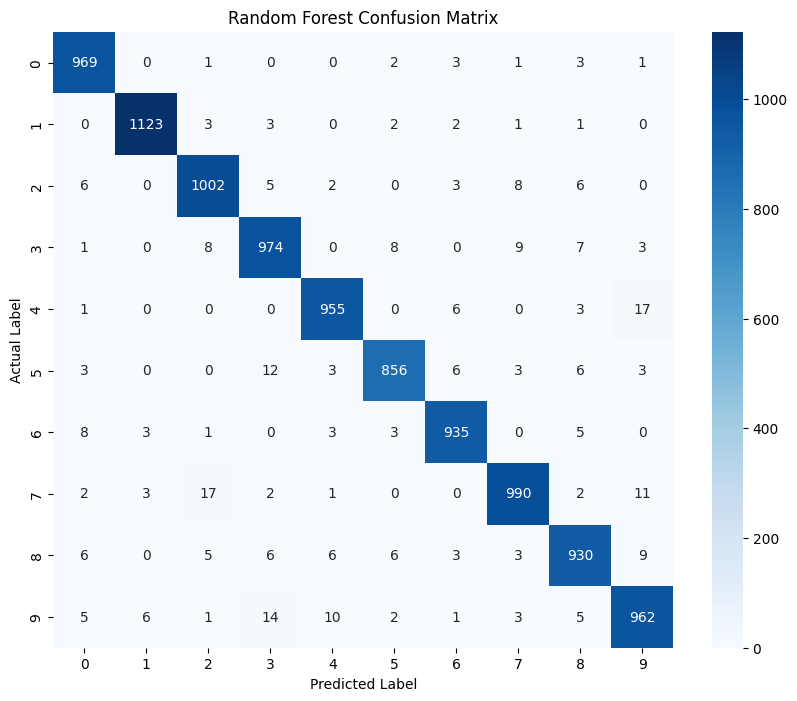

In [71]:
rf_cm = confusion_matrix(y_test,y_rf_test_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(rf_cm,annot=True,fmt="d",cmap="Blues",xticklabels=range(10),yticklabels=range(10))

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [73]:
# RANDOM FOREST FEATURE IMPORTANCE

feature_importance = rf_model.feature_importances_

print("Number of features:", len(feature_importance))
print("Total importance :", feature_importance.sum())

Number of features: 784
Total importance : 1.0


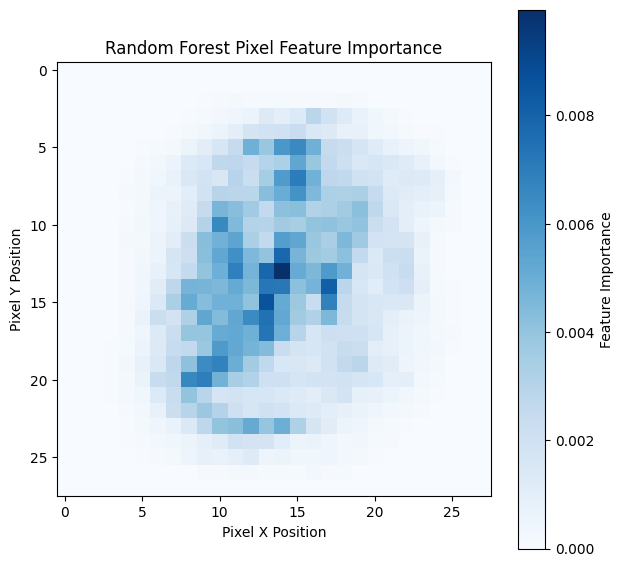

In [76]:
# FEATURE IMPORTANCE VISUALIZATION

importance_image = feature_importance.reshape(28, 28)

plt.figure(figsize=(7, 7))

plt.imshow(importance_image,cmap="Blues")

plt.colorbar(label="Feature Importance")

plt.title("Random Forest Pixel Feature Importance")
plt.xlabel("Pixel X Position")
plt.ylabel("Pixel Y Position")

plt.show()

In [77]:
model_results_df = pd.DataFrame(model_results)

model_results_df.sort_values(by="Accuracy",ascending=False).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1_Score
0,Support Vector Machine (RBF),0.9719,0.971923,0.9719,0.971880
1,K-Nearest Neighbors,0.9699,0.970090,0.9699,0.969853
2,Random Forest,0.9696,0.969612,0.9696,0.969585
3,Logistic Regression,0.9252,0.925074,0.9252,0.925051


# Neural Network with TensorFlow/Keras

In [78]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [79]:
X_train_nn = X_train_model.reshape(-1, 28, 28)
X_val_nn = X_val.reshape(-1, 28, 28)
X_test_nn = X_test_flat.reshape(-1, 28, 28)

print("Neural Network Training:", X_train_nn.shape)
print("Neural Network Validation:", X_val_nn.shape)
print("Neural Network Testing:", X_test_nn.shape)

Neural Network Training: (54000, 28, 28)
Neural Network Validation: (6000, 28, 28)
Neural Network Testing: (10000, 28, 28)


In [80]:
# BUILD NEURAL NETWORK

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense

nn_model = Sequential([
    Flatten(input_shape=(28, 28)),
    
    Dense(128, activation="relu"),
    
    Dense(64, activation="relu"),
    
    Dense(10, activation="softmax")
])

nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
nn_model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

print("Neural Network compiled successfully!")

Neural Network compiled successfully!


In [82]:
print("Training Neural Network...")

start_time = time.time()

history = nn_model.fit(X_train_nn,y_train_model,validation_data=(X_val_nn, y_val),epochs=10,batch_size=128,verbose=1)

nn_training_time = time.time() - start_time

print("\nNeural Network training completed!")
print(f"Training time: {nn_training_time:.2f} seconds")

Training Neural Network...
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8989 - loss: 0.3539 - val_accuracy: 0.9490 - val_loss: 0.1825
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9598 - loss: 0.1396 - val_accuracy: 0.9615 - val_loss: 0.1403
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9710 - loss: 0.0972 - val_accuracy: 0.9628 - val_loss: 0.1309
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9773 - loss: 0.0748 - val_accuracy: 0.9683 - val_loss: 0.1083
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9820 - loss: 0.0590 - val_accuracy: 0.9710 - val_loss: 0.1007
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9854 - loss: 0.0468 - val_accuracy: 0.9723 - val_loss: 0.0939
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9889 - loss: 0.0370 - val_accuracy: 0.9693 - val_loss: 0.1108
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9905 - loss

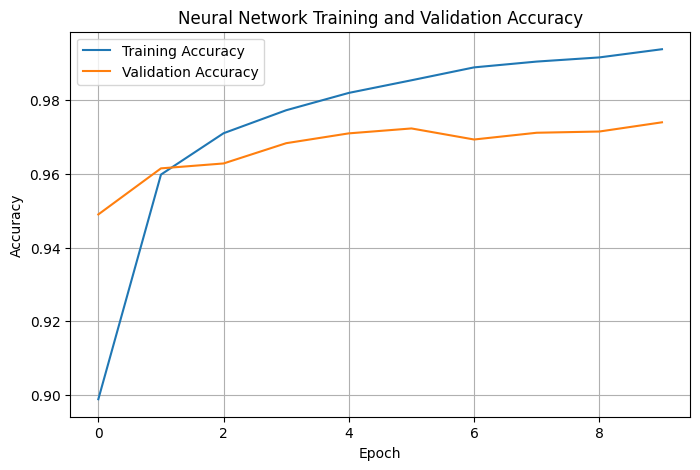

In [83]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Neural Network Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

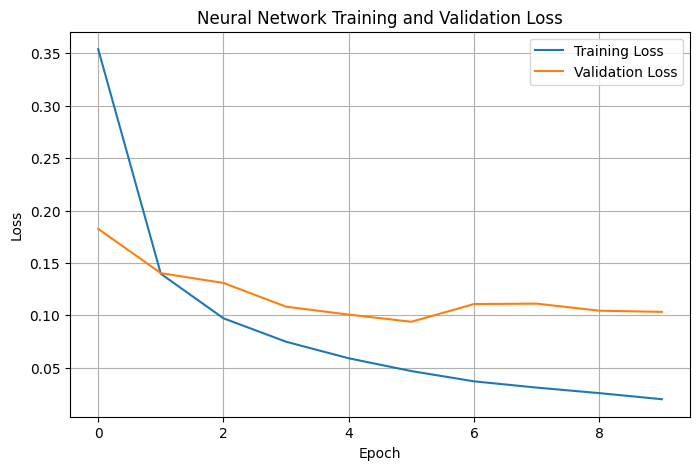

In [84]:
# NEURAL NETWORK LOSS

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Neural Network Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [85]:
# NEURAL NETWORK TEST EVALUATION

print("Evaluating Neural Network on test data...")

start_time = time.time()

test_loss, test_accuracy = nn_model.evaluate(X_test_nn,y_test,verbose=0)

nn_prediction_time = time.time() - start_time

print("Neural Network evaluation completed!")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Evaluation time: {nn_prediction_time:.2f} seconds")

Evaluating Neural Network on test data...
Neural Network evaluation completed!
Test Loss     : 0.0880
Test Accuracy : 0.9746
Evaluation time: 0.73 seconds


In [86]:
print("Generating Neural Network predictions...")

start_time = time.time()

nn_probabilities = nn_model.predict(X_test_nn,verbose=0)

y_nn_test_pred = np.argmax(nn_probabilities,axis=1)

nn_prediction_time = time.time() - start_time

print("Prediction completed!")
print(f"Prediction time: {nn_prediction_time:.2f} seconds")

Generating Neural Network predictions...
Prediction completed!
Prediction time: 0.71 seconds


In [87]:
nn_result = evaluate_model("Neural Network",y_test,y_nn_test_pred)

model_results.append(nn_result)

Neural Network
Accuracy : 0.9746
Precision: 0.9749
Recall   : 0.9746
F1 Score : 0.9746

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.98      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.95      0.98      0.97      1010
           4       0.98      0.97      0.98       982
           5       0.98      0.97      0.98       892
           6       0.99      0.97      0.98       958
           7       0.96      0.98      0.97      1028
           8       0.95      0.98      0.96       974
           9       0.98      0.94      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



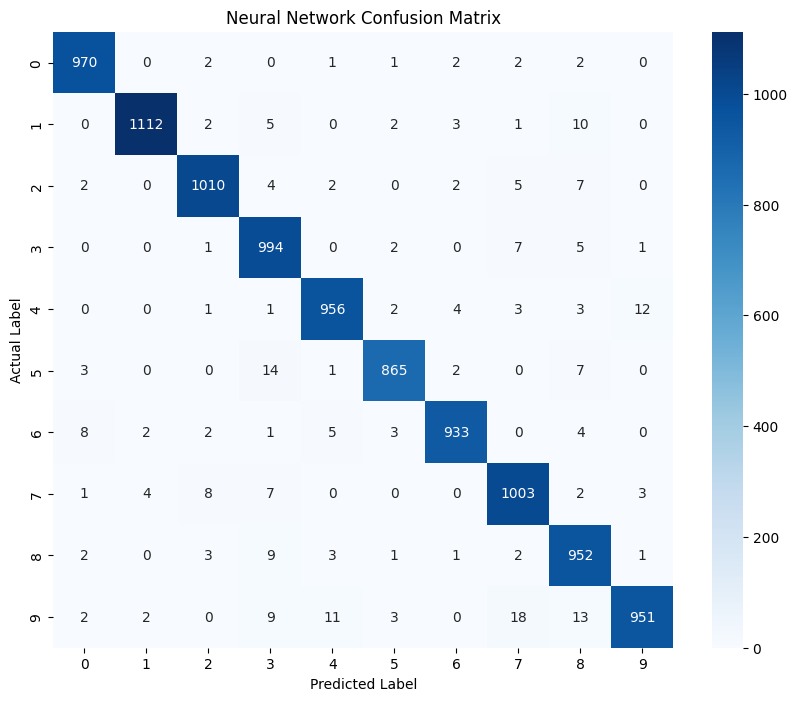

In [88]:
nn_cm = confusion_matrix(y_test,y_nn_test_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(nn_cm,annot=True,fmt="d",cmap="Blues",xticklabels=range(10),yticklabels=range(10))

plt.title("Neural Network Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [89]:
model_results_df = pd.DataFrame(model_results)

model_results_df = model_results_df.sort_values(by="Accuracy",ascending=False).reset_index(drop=True)

model_results_df

,Model,Accuracy,Precision,Recall,F1_Score
0,Neural Network,0.9746,0.974856,0.9746,0.974618
1,Support Vector Machine (RBF),0.9719,0.971923,0.9719,0.971880
2,K-Nearest Neighbors,0.9699,0.970090,0.9699,0.969853
3,Random Forest,0.9696,0.969612,0.9696,0.969585
4,Logistic Regression,0.9252,0.925074,0.9252,0.925051


# Complete Model Comparison & Visualization

In [90]:
final_results_df = pd.DataFrame(model_results)

final_results_df = final_results_df.sort_values(by="Accuracy",ascending=False).reset_index(drop=True)

final_results_df

,Model,Accuracy,Precision,Recall,F1_Score
0,Neural Network,0.9746,0.974856,0.9746,0.974618
1,Support Vector Machine (RBF),0.9719,0.971923,0.9719,0.971880
2,K-Nearest Neighbors,0.9699,0.970090,0.9699,0.969853
3,Random Forest,0.9696,0.969612,0.9696,0.969585
4,Logistic Regression,0.9252,0.925074,0.9252,0.925051


In [91]:
comparison_df = final_results_df.copy()

metric_columns = ["Accuracy","Precision","Recall","F1_Score"]

for col in metric_columns:
    comparison_df[col] = (
        comparison_df[col] * 100
    ).round(2)

comparison_df

,Model,Accuracy,Precision,Recall,F1_Score
0,Neural Network,97.46,97.49,97.46,97.46
1,Support Vector Machine (RBF),97.19,97.19,97.19,97.19
2,K-Nearest Neighbors,96.99,97.01,96.99,96.99
3,Random Forest,96.96,96.96,96.96,96.96
4,Logistic Regression,92.52,92.51,92.52,92.51


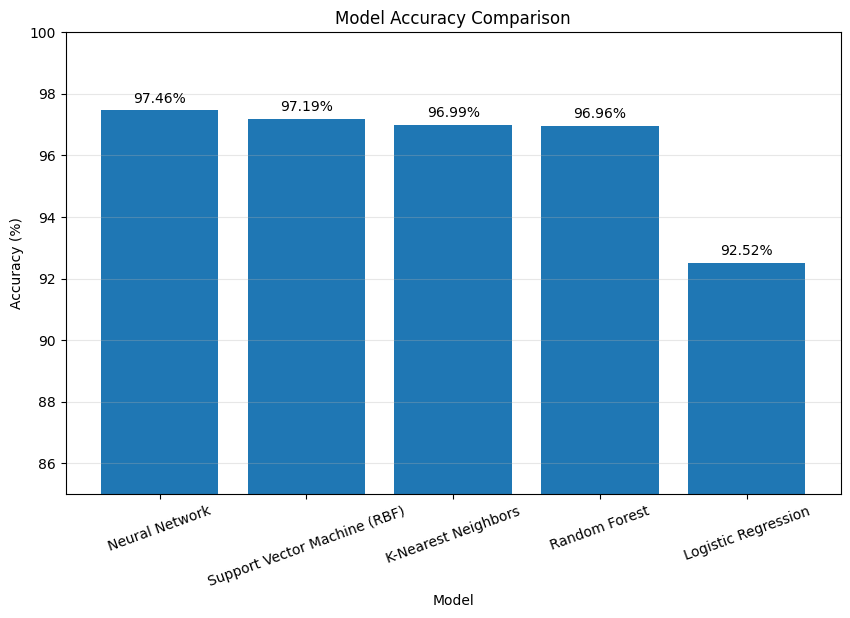

In [93]:
# MODEL ACCURACY COMPARISON

plt.figure(figsize=(10, 6))

bars = plt.bar(comparison_df["Model"],comparison_df["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")

plt.ylim(85, 100)
plt.xticks(rotation=20)

for bar, value in zip(
    bars,
    comparison_df["Accuracy"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.15,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)

plt.show()

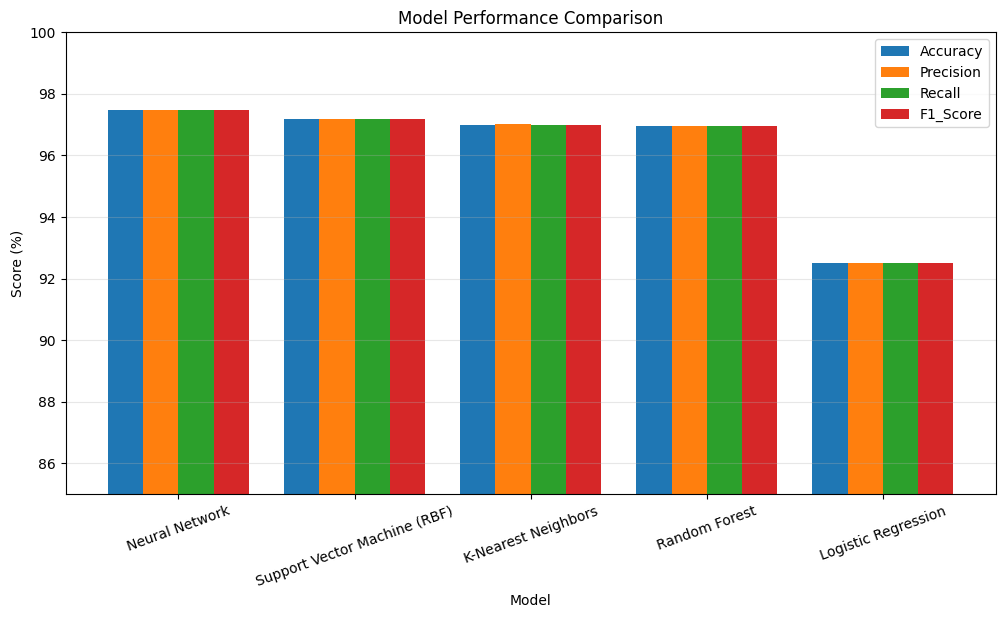

In [94]:
# PERFORMANCE METRICS COMPARISON

metrics_to_plot = ["Accuracy","Precision","Recall","F1_Score"]

plt.figure(figsize=(12, 6))

x = np.arange(len(comparison_df))
width = 0.2

for i, metric in enumerate(metrics_to_plot):
    
    plt.bar(x + i * width,comparison_df[metric],width,label=metric)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score (%)")

plt.xticks(x + width * 1.5,comparison_df["Model"],rotation=20)

plt.ylim(85, 100)
plt.legend()

plt.grid(axis="y", alpha=0.3)

plt.show()

In [95]:
# BEST MODEL

best_model_row = final_results_df.iloc[0]

best_model_name = best_model_row["Model"]
best_model_accuracy = best_model_row["Accuracy"]

print("Best Model:", best_model_name)
print(f"Best Accuracy: {best_model_accuracy * 100:.2f}%")

Best Model: Neural Network
Best Accuracy: 97.46%


In [96]:
# PERFORMANCE IMPROVEMENT

nn_accuracy = final_results_df.loc[final_results_df["Model"] == "Neural Network","Accuracy"].iloc[0]

lr_accuracy = final_results_df.loc[final_results_df["Model"] == "Logistic Regression","Accuracy"].iloc[0]

improvement = (nn_accuracy - lr_accuracy) * 100

print(
    f"Neural Network improvement over "
    f"Logistic Regression: {improvement:.2f} percentage points"
)

Neural Network improvement over Logistic Regression: 4.94 percentage points


In [97]:
# TRAINING TIME COMPARISON

training_time_df = pd.DataFrame({
    "Model": [
        "SVM (RBF)",
        "Logistic Regression",
        "Random Forest",
        "Neural Network"
    ],
    "Training_Time": [
        svm_training_time,
        logistic_training_time,
        rf_training_time,
        nn_training_time
    ]
})

training_time_df = training_time_df.sort_values("Training_Time")

training_time_df

,Model,Training_Time
2,Random Forest,14.100695
3,Neural Network,18.667075
1,Logistic Regression,26.039784
0,SVM (RBF),29.992748


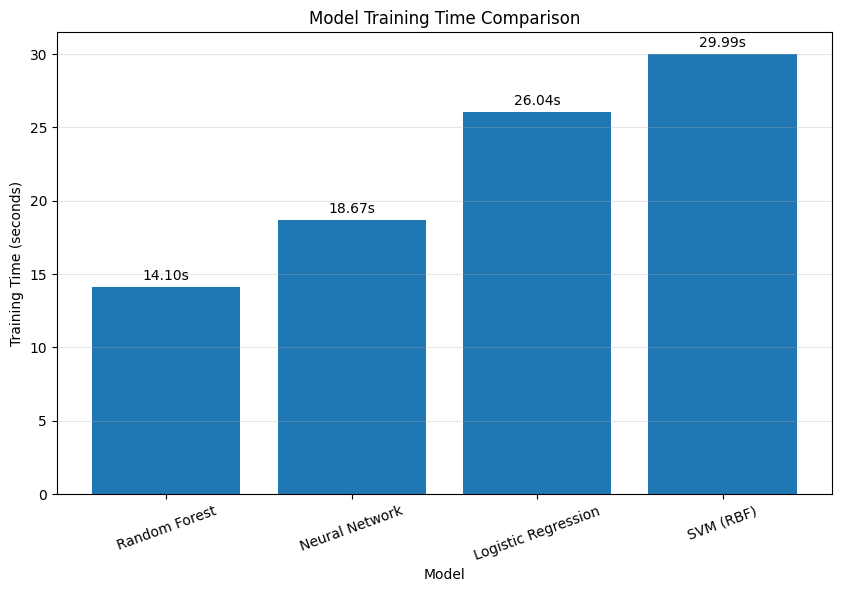

In [98]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    training_time_df["Model"],
    training_time_df["Training_Time"]
)

plt.title("Model Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")

plt.xticks(rotation=20)

for bar, value in zip(
    bars,
    training_time_df["Training_Time"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}s",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

plt.show()

In [99]:
# PREDICTION TIME COMPARISON

prediction_time_df = pd.DataFrame({
    "Model": [
        "SVM (RBF)",
        "Logistic Regression",
        "Random Forest",
        "Neural Network"
    ],
    "Prediction_Time": [
        svm_prediction_time,
        logistic_prediction_time,
        rf_prediction_time,
        nn_prediction_time
    ]
})

prediction_time_df = prediction_time_df.sort_values("Prediction_Time")

prediction_time_df

,Model,Prediction_Time
1,Logistic Regression,0.128911
2,Random Forest,0.230146
3,Neural Network,0.711820
0,SVM (RBF),33.258964


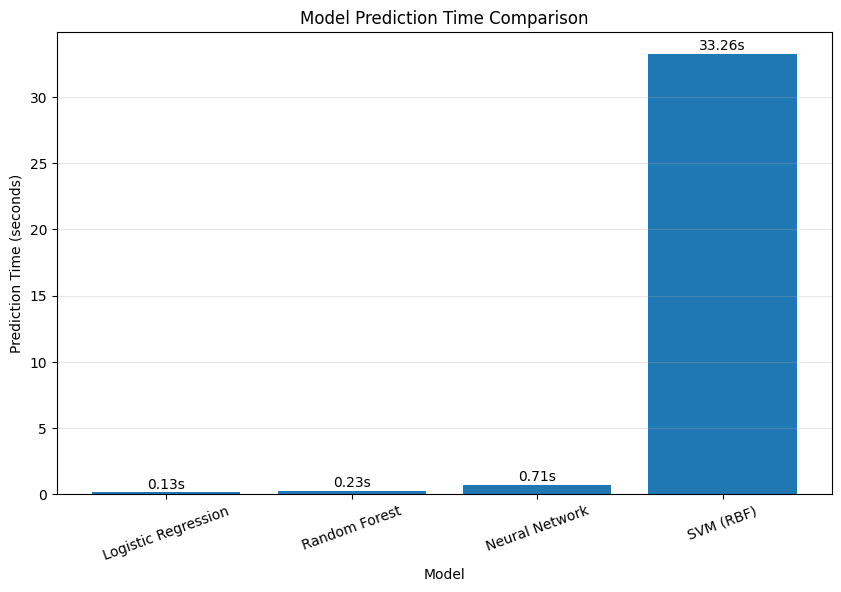

In [100]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    prediction_time_df["Model"],
    prediction_time_df["Prediction_Time"]
)

plt.title("Model Prediction Time Comparison")
plt.xlabel("Model")
plt.ylabel("Prediction Time (seconds)")

plt.xticks(rotation=20)

for bar, value in zip(
    bars,
    prediction_time_df["Prediction_Time"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.3,
        f"{value:.2f}s",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

plt.show()

In [101]:
# FINAL SUMMARY TABLE

final_summary = comparison_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1_Score"
    ]
].copy()

final_summary

,Model,Accuracy,Precision,Recall,F1_Score
0,Neural Network,97.46,97.49,97.46,97.46
1,Support Vector Machine (RBF),97.19,97.19,97.19,97.19
2,K-Nearest Neighbors,96.99,97.01,96.99,96.99
3,Random Forest,96.96,96.96,96.96,96.96
4,Logistic Regression,92.52,92.51,92.52,92.51


## Model Comparison Analysis

Five classification models were evaluated on the MNIST handwritten digit
dataset: K-Nearest Neighbors, Support Vector Machine with an RBF kernel,
Logistic Regression, Random Forest, and a fully connected Neural Network.

The Neural Network achieved the highest test accuracy of 97.46%, followed
by SVM with 97.19%, KNN with 96.99%, Random Forest with 96.96%, and Logistic
Regression with 92.52%.

The Neural Network also achieved the highest F1-score of 97.46%, indicating
strong overall classification performance.

SVM performed competitively with an accuracy of 97.19%, while KNN and Random
Forest achieved approximately 97% accuracy. Logistic Regression produced
the lowest accuracy among the evaluated models at 92.52%, suggesting that
the linear decision boundaries were less effective for this handwritten
digit classification problem.

Although the Neural Network achieved the highest predictive performance,
model selection should also consider computational cost and prediction
speed. The final production recommendation will therefore consider both
classification performance and practical deployment requirements.

# Neural Network Error Analysis

In [102]:
# TOTAL CLASSIFICATION ERRORS

total_test_images = len(y_test)

correct_predictions = np.sum(y_nn_test_pred == y_test)

incorrect_predictions = np.sum(y_nn_test_pred != y_test)

error_rate = (incorrect_predictions / total_test_images) * 100

accuracy = (correct_predictions / total_test_images) * 100

print("Total test images       :", total_test_images)
print("Correct predictions     :", correct_predictions)
print("Incorrect predictions   :", incorrect_predictions)
print(f"Accuracy                : {accuracy:.2f}%")
print(f"Error Rate              : {error_rate:.2f}%")

Total test images       : 10000
Correct predictions     : 9746
Incorrect predictions   : 254
Accuracy                : 97.46%
Error Rate              : 2.54%


In [103]:
# FIND MISCLASSIFIED IMAGES

misclassified_indices = np.where(y_nn_test_pred != y_test)[0]

print("Number of misclassified images:",len(misclassified_indices))

print("\nFirst 20 misclassified indexes:")
print(misclassified_indices[:20])

Number of misclassified images: 254

First 20 misclassified indexes:
[ 18 151 241 247 259 273 274 320 321 381 434 445 448 495 582 619 659 684
 720 726]


In [104]:
# MISCLASSIFICATION TABLE

misclassified_df = pd.DataFrame({
    "Image_Index": misclassified_indices,
    "Actual_Label": y_test[misclassified_indices],
    "Predicted_Label": y_nn_test_pred[misclassified_indices]
})

misclassified_df.head(20)

,Image_Index,Actual_Label,Predicted_Label
0,18,3,8
1,151,9,8
2,241,9,8
3,247,4,6
4,259,6,0
5,273,9,3
6,274,9,3
7,320,9,8
8,321,2,7
9,381,3,7


In [105]:
# MOST COMMON MISCLASSIFICATIONS

misclassification_pairs = (
    misclassified_df
    .groupby(
        ["Actual_Label", "Predicted_Label"]
    )
    .size()
    .reset_index(name="Count")
    .sort_values("Count",ascending=False)
    .reset_index(drop=True)
)

misclassification_pairs.head(15)

,Actual_Label,Predicted_Label,Count
0,9,7,18
1,5,3,14
2,9,8,13
3,4,9,12
4,9,4,11
5,1,8,10
6,8,3,9
7,9,3,9
8,7,2,8
9,6,0,8


In [106]:
# PER-DIGIT ERROR RATE

per_digit_analysis = []

for digit in range(10):
    
    digit_mask = (y_test == digit)
    
    total_digit_images = np.sum(digit_mask)
    
    incorrect_digit_predictions = np.sum((y_test == digit) & (y_nn_test_pred != digit))
    
    correct_digit_predictions = (total_digit_images - incorrect_digit_predictions)
    
    digit_accuracy = (correct_digit_predictions /total_digit_images) * 100
    
    digit_error_rate = (incorrect_digit_predictions /total_digit_images) * 100
    
    per_digit_analysis.append({
        "Digit": digit,
        "Total": total_digit_images,
        "Correct": correct_digit_predictions,
        "Incorrect": incorrect_digit_predictions,
        "Accuracy": digit_accuracy,
        "Error_Rate": digit_error_rate
    })

per_digit_df = pd.DataFrame(per_digit_analysis)

per_digit_df

,Digit,Total,Correct,Incorrect,Accuracy,Error_Rate
0,0,980,970,10,98.979592,1.020408
1,1,1135,1112,23,97.973568,2.026432
2,2,1032,1010,22,97.868217,2.131783
3,3,1010,994,16,98.415842,1.584158
4,4,982,956,26,97.352342,2.647658
5,5,892,865,27,96.973094,3.026906
6,6,958,933,25,97.390397,2.609603
7,7,1028,1003,25,97.568093,2.431907
8,8,974,952,22,97.741273,2.258727
9,9,1009,951,58,94.251734,5.748266


In [107]:
# SORT BY ERROR RATE

per_digit_df.sort_values("Error_Rate",ascending=False).reset_index(drop=True)

,Digit,Total,Correct,Incorrect,Accuracy,Error_Rate
0,9,1009,951,58,94.251734,5.748266
1,5,892,865,27,96.973094,3.026906
2,4,982,956,26,97.352342,2.647658
3,6,958,933,25,97.390397,2.609603
4,7,1028,1003,25,97.568093,2.431907
5,8,974,952,22,97.741273,2.258727
6,2,1032,1010,22,97.868217,2.131783
7,1,1135,1112,23,97.973568,2.026432
8,3,1010,994,16,98.415842,1.584158
9,0,980,970,10,98.979592,1.020408


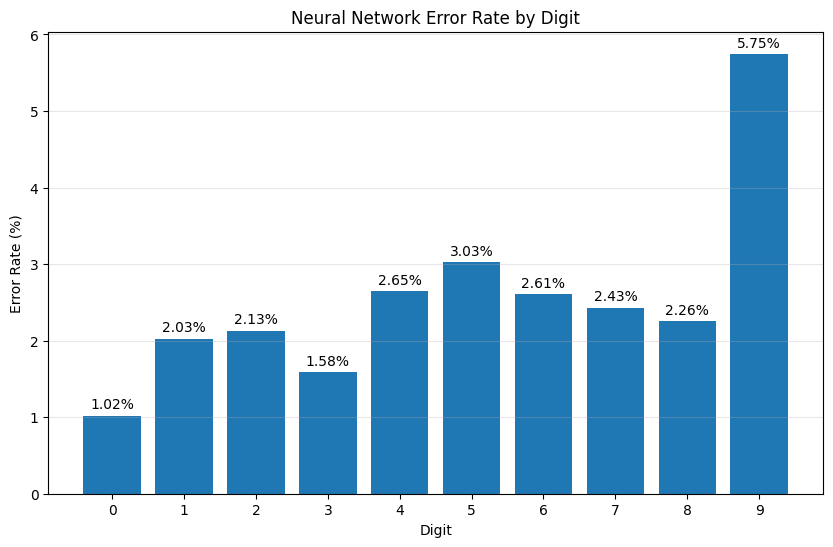

In [108]:
# PER-DIGIT ERROR RATE CHART

plt.figure(figsize=(10, 6))

bars = plt.bar(
    per_digit_df["Digit"],
    per_digit_df["Error_Rate"]
)

plt.title("Neural Network Error Rate by Digit")
plt.xlabel("Digit")
plt.ylabel("Error Rate (%)")

plt.xticks(range(10))

for bar, value in zip(
    bars,
    per_digit_df["Error_Rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.05,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)

plt.show()

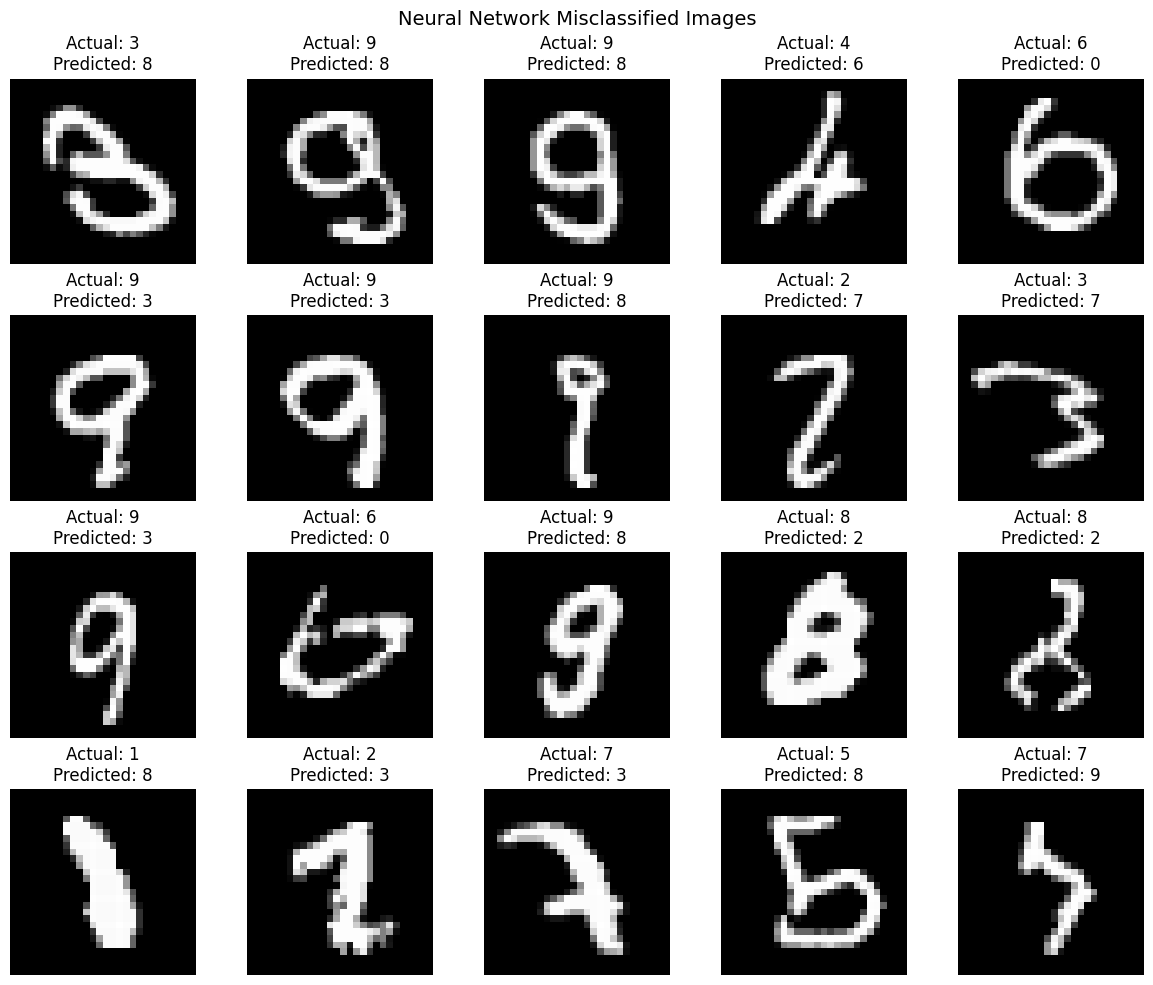

In [109]:
# VISUALIZE MISCLASSIFIED IMAGES

num_images = min(20,len(misclassified_indices))

plt.figure(figsize=(12, 10))

for i in range(num_images):
    
    index = misclassified_indices[i]
    
    plt.subplot(4, 5, i + 1)
    
    plt.imshow(X_test_nn[index],cmap="gray")
    
    plt.title(
        f"Actual: {y_test[index]}\n"
        f"Predicted: {y_nn_test_pred[index]}"
    )
    
    plt.axis("off")

plt.suptitle("Neural Network Misclassified Images",fontsize=14)

plt.tight_layout()

plt.show()

In [110]:
# PREDICTION CONFIDENCE

prediction_confidence = np.max(nn_probabilities,axis=1)

print("Average prediction confidence:",prediction_confidence.mean())

print("Minimum prediction confidence:",prediction_confidence.min())

print("Maximum prediction confidence:",prediction_confidence.max())

Average prediction confidence: 0.98439825
Minimum prediction confidence: 0.24454652
Maximum prediction confidence: 1.0


In [111]:
# MISCLASSIFIED CONFIDENCE

misclassified_confidence = prediction_confidence[misclassified_indices]

print("Average confidence on misclassified images:",misclassified_confidence.mean())

print("Minimum confidence on misclassified images:",misclassified_confidence.min())

print("Maximum confidence on misclassified images:",misclassified_confidence.max())

Average confidence on misclassified images: 0.7771818
Minimum confidence on misclassified images: 0.24454652
Maximum confidence on misclassified images: 0.9999733


In [112]:
# MOST CONFIDENT WRONG PREDICTIONS

confident_wrong_indices = misclassified_indices[np.argsort(misclassified_confidence)[::-1]]

confident_wrong_indices[:10]

array([3520, 9587, 4880, 2654, 2939,  619, 1226, 1681, 3906, 1014])

In [113]:
# CONFIDENT WRONG PREDICTIONS TABLE

confident_wrong_df = pd.DataFrame({
    "Image_Index": confident_wrong_indices[:10],
    "Actual_Label": y_test[confident_wrong_indices[:10]],
    "Predicted_Label": y_nn_test_pred[
        confident_wrong_indices[:10]
    ],
    "Confidence": prediction_confidence[
        confident_wrong_indices[:10]
    ]
})

confident_wrong_df

,Image_Index,Actual_Label,Predicted_Label,Confidence
0,3520,6,4,0.999973
1,9587,9,4,0.999903
2,4880,0,8,0.999896
3,2654,6,1,0.999882
4,2939,9,7,0.999443
5,619,1,8,0.998682
6,1226,7,2,0.998515
7,1681,3,7,0.998296
8,3906,1,3,0.998207
9,1014,6,5,0.998179


In [114]:
confident_wrong_df["Confidence"] = (confident_wrong_df["Confidence"] * 100).round(2)

confident_wrong_df

,Image_Index,Actual_Label,Predicted_Label,Confidence
0,3520,6,4,100.000000
1,9587,9,4,99.989998
2,4880,0,8,99.989998
3,2654,6,1,99.989998
4,2939,9,7,99.940002
5,619,1,8,99.870003
6,1226,7,2,99.849998
7,1681,3,7,99.830002
8,3906,1,3,99.820000
9,1014,6,5,99.820000


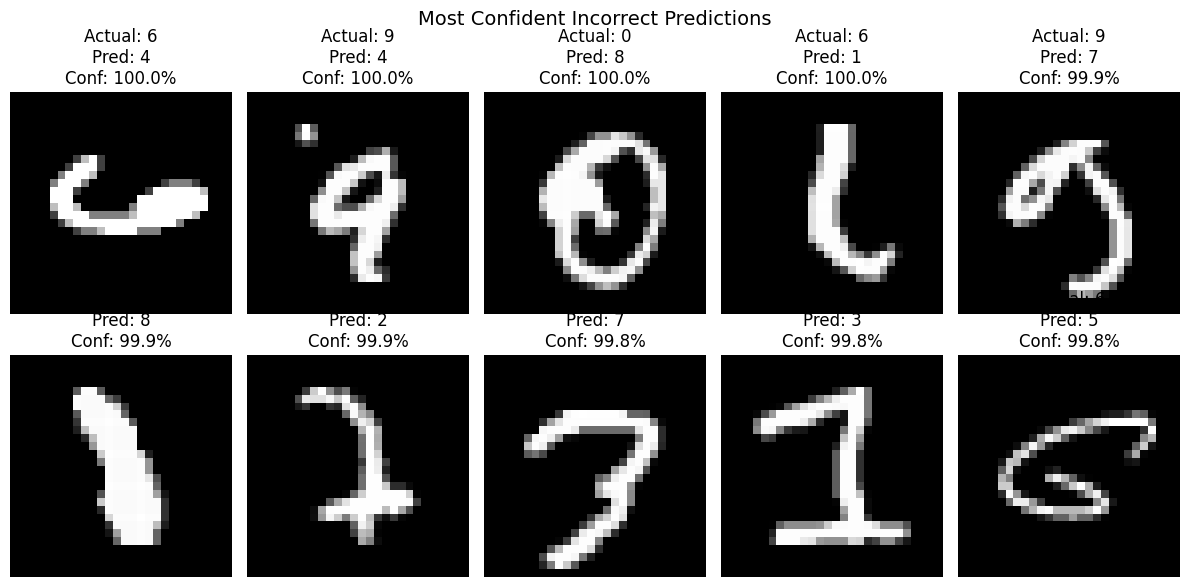

In [115]:
# CONFIDENT WRONG IMAGES

num_images = min(10,len(confident_wrong_indices))

plt.figure(figsize=(12, 6))

for i in range(num_images):
    
    index = confident_wrong_indices[i]
    
    plt.subplot(2, 5, i + 1)
    
    plt.imshow(X_test_nn[index],cmap="gray")
    
    confidence = prediction_confidence[index] * 100
    
    plt.title(
        f"Actual: {y_test[index]}\n"
        f"Pred: {y_nn_test_pred[index]}\n"
        f"Conf: {confidence:.1f}%"
    )
    
    plt.axis("off")

plt.suptitle("Most Confident Incorrect Predictions",fontsize=14)

plt.tight_layout()

plt.show()

## Neural Network Error Analysis

The Neural Network correctly classified 9,746 out of 10,000 test images,
resulting in an accuracy of 97.46% and an error rate of 2.54%. A total of
254 test images were incorrectly classified.

Per-digit analysis showed that digit 0 was classified most accurately, with
an accuracy of 98.98% and an error rate of only 1.02%. Digit 9 was the most
difficult class, with an accuracy of 94.25% and an error rate of 5.75%.

The most common misclassification was actual digit 9 being predicted as 7,
with 18 errors. Other frequent confusion patterns included 5 being
predicted as 3, 9 as 8, and 4 as 9.

The average prediction confidence across all test images was 98.44%.
However, the average confidence for incorrectly classified images was
77.72%. This indicates that the model was generally less confident on
difficult examples.

Interestingly, some incorrect predictions had extremely high confidence.
The highest-confidence incorrect prediction had a confidence of
approximately 99.997%. This demonstrates that prediction probability
should not always be interpreted as certainty.

The observed errors may be caused by similarities between handwritten
digit shapes, variations in handwriting styles, ambiguous images, and the
limitations of the fully connected neural network architecture.

Overall, the model demonstrated strong generalization performance, but the
error analysis identified specific digit classes and ambiguous examples
where further improvement could be explored.

# Handwritten Digit Prediction 

In [117]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def predict_handwritten_digit(image_path, model):
    
    # Load image
    image = Image.open(image_path).convert("L")
    
    # Resize to MNIST dimensions
    image = image.resize((28, 28))
    
    # Convert to NumPy array
    image_array = np.array(image)
    
    # Display original grayscale image
    plt.figure(figsize=(4, 4))
    plt.imshow(image_array, cmap="gray")
    plt.title("Input Image")
    plt.axis("off")
    plt.show()
    
    # Check pixel range
    print("Original pixel range:")
    print("Minimum:", image_array.min())
    print("Maximum:", image_array.max())
    
    # Normalize pixel values
    image_normalized = image_array.astype("float32") / 255.0
    
    # Add batch dimension
    image_input = np.expand_dims(image_normalized,axis=0)
    
    # Generate prediction
    probabilities = model.predict(image_input,verbose=0)
    
    # Get predicted digit
    predicted_digit = np.argmax(probabilities[0])
    
    # Get confidence
    confidence = np.max(probabilities[0])
    
    print("\nPrediction Results")
    print("Predicted Digit :", predicted_digit)
    print(f"Confidence      : {confidence * 100:.2f}%")
    
    return predicted_digit, confidence, probabilities[0]

In [118]:
# IMPROVED HANDWRITTEN PREDICTION

def predict_handwritten_digit(image_path,model,invert=False):
    
    # Load image as grayscale
    image = Image.open(image_path).convert("L")
    
    # Resize to MNIST size
    image = image.resize((28, 28))
    
    # Convert to NumPy array
    image_array = np.array(image)
    
    # Invert image if required
    if invert:
        image_array = 255 - image_array
    
    # Normalize
    image_normalized = (image_array.astype("float32") / 255.0)
    
    # Add batch dimension
    image_input = np.expand_dims(image_normalized,axis=0)
    
    # Predict
    probabilities = model.predict(image_input,verbose=0)[0]
    
    # Predicted digit
    predicted_digit = np.argmax(probabilities)
    
    # Confidence
    confidence = np.max(probabilities)
    
    # Display processed image
    plt.figure(figsize=(4, 4))
    
    plt.imshow(image_normalized,cmap="gray")
    
    plt.title(
        f"Predicted Digit: {predicted_digit}\n"
        f"Confidence: {confidence * 100:.2f}%"
    )
    
    plt.axis("off")
    plt.show()
    
    print("HANDWRITTEN DIGIT PREDICTION")
    print("Predicted Digit :", predicted_digit)
    print(
        f"Confidence      : {confidence * 100:.2f}%"
    )
    
    return (
        predicted_digit,
        confidence,
        probabilities
    )

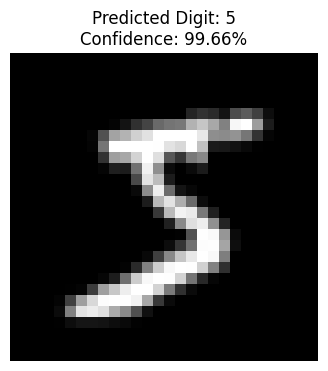

HANDWRITTEN DIGIT PREDICTION
Predicted Digit : 5
Confidence      : 99.66%


In [125]:
predicted_digit, confidence, probabilities = (
    predict_handwritten_digit(
        "MNIST_5.webp",
        nn_model,
        invert=False
    )
)

In [126]:
# DIGIT PROBABILITY DISTRIBUTION

digit_probabilities = probabilities * 100

probability_df = pd.DataFrame({
    "Digit": range(10),
    "Probability": digit_probabilities
})

probability_df

,Digit,Probability
0,0,8.629739e-06
1,1,3.359792e-07
2,2,2.800106e-04
3,3,3.415518e-01
4,4,1.354926e-10
5,5,9.965650e+01
6,6,5.356798e-08
7,7,1.632452e-03
8,8,6.742737e-06
9,9,1.011172e-05


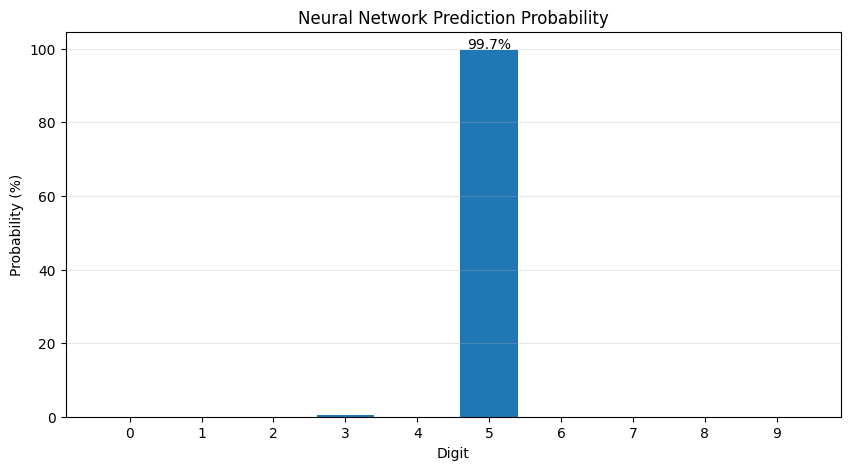

In [127]:
# PREDICTION PROBABILITY CHART

plt.figure(figsize=(10, 5))

bars = plt.bar(
    probability_df["Digit"],
    probability_df["Probability"]
)

plt.title("Neural Network Prediction Probability")

plt.xlabel("Digit")
plt.ylabel("Probability (%)")

plt.xticks(range(10))

for bar, value in zip(
    bars,
    probability_df["Probability"]
):
    
    if value > 1:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.5,
            f"{value:.1f}%",
            ha="center"
        )

plt.grid(axis="y",alpha=0.3)

plt.show()

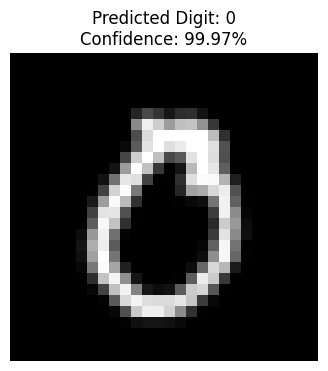

HANDWRITTEN DIGIT PREDICTION
Predicted Digit : 0
Confidence      : 99.97%


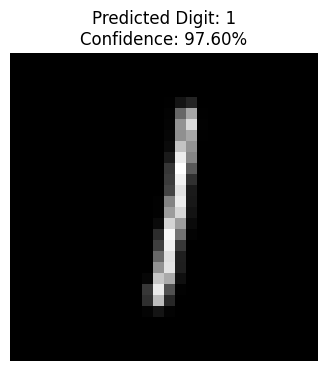

HANDWRITTEN DIGIT PREDICTION
Predicted Digit : 1
Confidence      : 97.60%


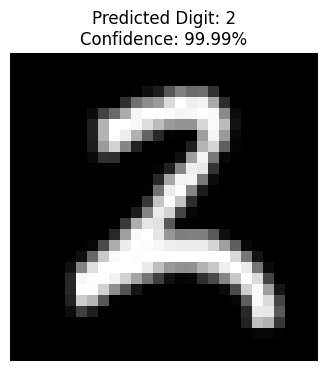

HANDWRITTEN DIGIT PREDICTION
Predicted Digit : 2
Confidence      : 99.99%


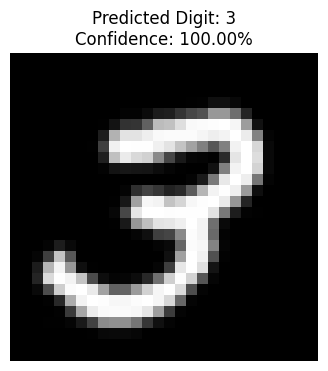

HANDWRITTEN DIGIT PREDICTION
Predicted Digit : 3
Confidence      : 100.00%


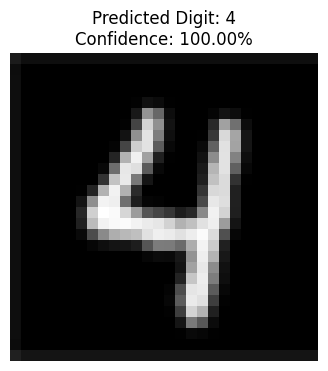

HANDWRITTEN DIGIT PREDICTION
Predicted Digit : 4
Confidence      : 100.00%


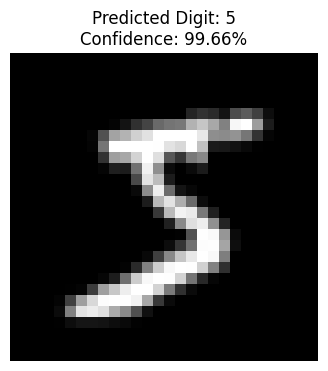

HANDWRITTEN DIGIT PREDICTION
Predicted Digit : 5
Confidence      : 99.66%


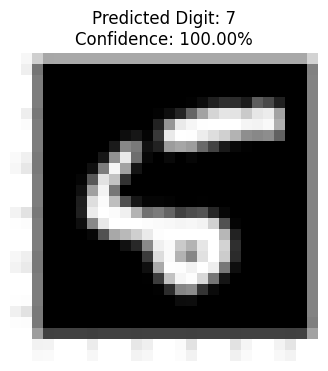

HANDWRITTEN DIGIT PREDICTION
Predicted Digit : 7
Confidence      : 100.00%


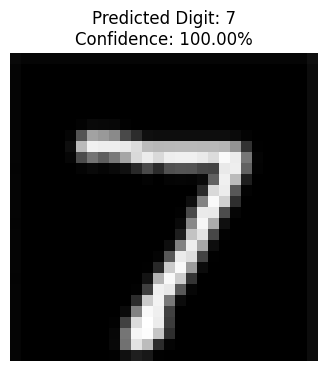

HANDWRITTEN DIGIT PREDICTION
Predicted Digit : 7
Confidence      : 100.00%


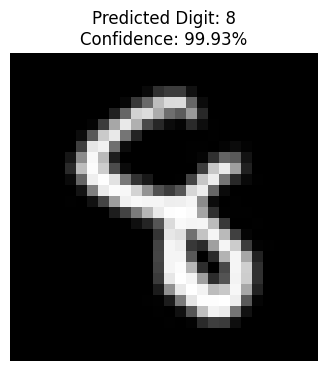

HANDWRITTEN DIGIT PREDICTION
Predicted Digit : 8
Confidence      : 99.93%


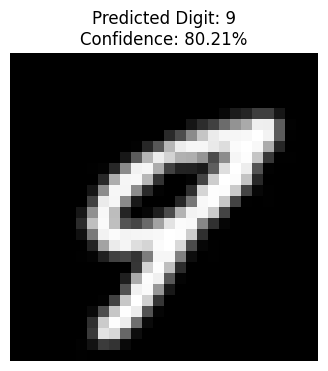

HANDWRITTEN DIGIT PREDICTION
Predicted Digit : 9
Confidence      : 80.21%


,Image,Predicted_Digit,Confidence
0,MNIST_0.webp,0,99.968658
1,MNIST_1.webp,1,97.600662
2,MNIST_2.jpg,2,99.994576
3,MNIST_3.webp,3,100.000000
4,MNIST_4.png,4,99.999130
5,MNIST_5.webp,5,99.656502
6,MNIST_6.png,7,100.000000
7,MNIST_7.webp,7,99.999725
8,MNIST_8.jpg,8,99.931023
9,MNIST_9.jpg,9,80.205582


In [129]:
# MULTIPLE IMAGE PREDICTION

image_paths = [
    "MNIST_0.webp",
    "MNIST_1.webp",
    "MNIST_2.jpg",
    "MNIST_3.webp",
    "MNIST_4.png",
    "MNIST_5.webp",
    "MNIST_6.png",
    "MNIST_7.webp",
    "MNIST_8.jpg",
    "MNIST_9.jpg"
]

prediction_results = []

for image_path in image_paths:
    
    predicted_digit, confidence, _ = (
        predict_handwritten_digit(
            image_path,
            nn_model,
            invert=False
        )
    )
    
    prediction_results.append({
        "Image": image_path,
        "Predicted_Digit": predicted_digit,
        "Confidence": confidence * 100
    })

handwritten_results_df = pd.DataFrame(prediction_results)

handwritten_results_df

## Handwritten Digit Prediction

The trained Neural Network was used to predict previously unseen handwritten
digit images.

A preprocessing pipeline was implemented to convert an input image into the
same general format expected by the MNIST-trained model. The image is
converted to grayscale, resized to 28 × 28 pixels, optionally inverted to
match the MNIST pixel representation, normalized to the range [0, 1], and
passed to the trained Neural Network.

The model outputs probabilities for all ten digit classes (0–9). The class
with the highest probability is selected as the predicted digit.

This demonstrates how the trained classification model can be applied to
new handwritten digit images rather than only evaluating the predefined
MNIST test dataset.

# Production Model Recommendation

In [130]:
# PRODUCTION MODEL COMPARISON

production_comparison = final_results_df.copy()

production_comparison[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1_Score"
    ]
]

,Model,Accuracy,Precision,Recall,F1_Score
0,Neural Network,0.9746,0.974856,0.9746,0.974618
1,Support Vector Machine (RBF),0.9719,0.971923,0.9719,0.971880
2,K-Nearest Neighbors,0.9699,0.970090,0.9699,0.969853
3,Random Forest,0.9696,0.969612,0.9696,0.969585
4,Logistic Regression,0.9252,0.925074,0.9252,0.925051


### Production Model Recommendation

Five machine learning models were evaluated for handwritten digit
classification: Logistic Regression, Random Forest, K-Nearest Neighbors,
Support Vector Machine with RBF kernel, and a Neural Network.

The Neural Network achieved the highest test accuracy of **97.46%**, with
precision of **97.49%**, recall of **97.46%**, and F1-score of **97.46%**.

The Support Vector Machine was the second-best model with an accuracy of
97.19%, followed by K-Nearest Neighbors at 96.99%, Random Forest at 96.96%,
and Logistic Regression at 92.52%.

Based on the overall predictive performance, the Neural Network was selected
as the final model for the handwritten digit recognition system.

The Neural Network also provides class probability scores, allowing the
system to return both the predicted digit and prediction confidence. During
custom testing, the model successfully predicted a handwritten digit 5 with
99.66% confidence.

Therefore, the Neural Network provides the best overall combination of
accuracy, classification performance, probability estimation, and practical
applicability for this MNIST handwritten digit recognition project.

# Save the Final Model 

In [131]:
nn_model.save("mnist_digit_classifier.keras")

print("Final Neural Network model saved successfully!")

Final Neural Network model saved successfully!


In [132]:
from tensorflow.keras.models import load_model

loaded_model = load_model("mnist_digit_classifier.keras")

print("Saved model loaded successfully!")

Saved model loaded successfully!


In [133]:
test_loss, test_accuracy = loaded_model.evaluate(X_test_nn,y_test,verbose=0)

print("Loaded Model Test Accuracy:",f"{test_accuracy * 100:.2f}%")

Loaded Model Test Accuracy: 97.46%


# Final Project Packaging & Documentation

### Key Exploratory Data Analysis Findings

The dataset contains 60,000 training images and 10,000 testing images.
Each image is a 28 × 28 grayscale image containing 784 pixels.

The pixel values range from 0 to 255. The mean pixel intensity of the
training dataset is approximately 33.32, while the standard deviation is
approximately 78.57.

Approximately 80.88% of all training pixels have a value of zero,
representing the background, while approximately 19.12% are non-background
pixels.

The class distribution is relatively balanced, although some variation
exists between digits. Digit 1 has the highest number of training examples,
while digit 5 has the lowest.

No missing values were found in the training or testing images or labels,
and no duplicate training images were detected.

# Model Comparison Report

Multiple classification algorithms were trained and evaluated on the MNIST
dataset.

The models evaluated were:

- Logistic Regression
- Random Forest
- K-Nearest Neighbors
- Support Vector Machine with RBF kernel
- Neural Network 


| Rank | Model               |   Accuracy |  Precision |     Recall |   F1 Score |
| ---: | ------------------- | ---------: | ---------: | ---------: | ---------: |
|    1 | **Neural Network**  | **97.46%** | **97.49%** | **97.46%** | **97.46%** |
|    2 | SVM (RBF)           |     97.19% |     97.19% |     97.19% |     97.19% |
|    3 | KNN                 |     96.99% |     97.01% |     96.99% |     96.99% |
|    4 | Random Forest       |     96.96% |     96.96% |     96.96% |     96.96% |
|    5 | Logistic Regression |     92.52% |     92.51% |     92.52% |     92.51% |


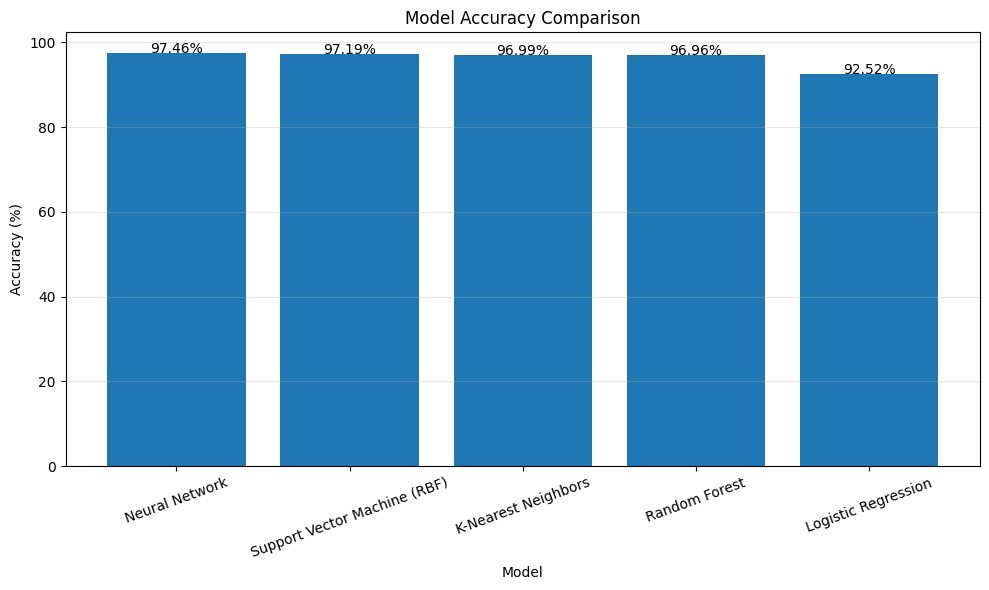

In [134]:
# MODEL ACCURACY COMPARISON
comparison_plot = final_results_df.sort_values("Accuracy",ascending=False)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    comparison_plot["Model"],
    comparison_plot["Accuracy"] * 100
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")

plt.xticks(rotation=20)

for bar, value in zip(
    bars,
    comparison_plot["Accuracy"] * 100
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.1,
        f"{value:.2f}%",
        ha="center"
    )

plt.grid(axis="y",alpha=0.3)

plt.tight_layout()
plt.show()

# Production Model Recommendation


Based on the experimental results, the Neural Network is selected as the
final production model.

The Neural Network achieved the highest accuracy of 97.46% and the highest
F1-score of 97.46% among all evaluated models.

The model also performed strongly across the ten digit classes and
successfully predicted a custom handwritten digit during testing.

Another advantage of the Neural Network is that it provides probability
scores for all ten classes. This allows the application to provide both a
predicted digit and a confidence score.

Therefore, the Neural Network provides the best overall predictive
performance for this handwritten digit recognition task.

# Challenges Faced and Solutions

## 1. Dataset Access

### Challenge
The originally provided dataset download link was not accessible.

### Solution
The MNIST dataset was loaded directly using TensorFlow/Keras, which provided
the standard MNIST training and testing datasets.

---

## 2. Image Representation

### Challenge
The original images were stored as 28 × 28 grayscale pixel arrays rather
than conventional tabular features.

### Solution
The images were analyzed in their original 28 × 28 format for image
visualization and converted into 784-dimensional feature vectors for
traditional machine learning algorithms.

---

## 3. Pixel Scaling

### Challenge
Original pixel values ranged from 0 to 255, which is not ideal for several
machine learning algorithms.

### Solution
Pixel values were normalized by dividing by 255, resulting in values between
0 and 1.

---

## 4. High Dimensionality

### Challenge
Each image contains 784 pixel features, creating a relatively
high-dimensional feature space.

### Solution
The images were flattened into 784-dimensional vectors for traditional
machine learning algorithms. The Neural Network used a Flatten layer before
the dense layers.

---

## 5. Model Selection

### Challenge
Different algorithms produced different levels of predictive performance.

### Solution
Multiple models were trained and evaluated using accuracy, precision,
recall, and F1-score. The Neural Network achieved the highest overall
performance and was selected as the final model.

---

## 6. Misclassification

### Challenge
Some handwritten digits have visually similar shapes, making them difficult
to distinguish.

### Solution
Error analysis was performed using misclassification pairs, per-digit error
rates, and visualization of incorrectly classified images.

Digit 9 showed the highest error rate at approximately 5.75%, while digit 0
had the lowest error rate at approximately 1.02%.

---

## 7. Custom Handwritten Images

### Challenge
Custom handwritten images may have a different background and pixel
orientation from the MNIST dataset.

### Solution
A preprocessing pipeline was implemented that converts images to grayscale,
resizes them to 28 × 28 pixels, normalizes the pixel values, and optionally
inverts the image to match the MNIST representation.

# Final Conclusion


This project successfully developed a handwritten digit recognition system
using the MNIST dataset.

The dataset was analyzed through exploratory data analysis, image analysis,
pixel-level analysis, and class distribution analysis. Appropriate
preprocessing techniques were applied, including pixel normalization and
conversion of images into feature vectors for traditional machine learning
models.

Five classification approaches were evaluated: Logistic Regression, Random
Forest, K-Nearest Neighbors, Support Vector Machine, and Neural Network.

Among all evaluated models, the Neural Network achieved the best performance
with an accuracy of 97.46%, precision of 97.49%, recall of 97.46%, and
F1-score of 97.46%.

The model was further evaluated through error analysis and successfully
predicted a custom handwritten digit 5 with 99.66% confidence.

Overall, the project demonstrates the complete machine learning workflow
from dataset loading and exploratory analysis to preprocessing, model
comparison, error analysis, custom prediction, and final model selection.

# Final Model Saving

In [135]:
# SAVE FINAL PRODUCTION MODEL

nn_model.save("mnist_digit_classifier.keras")

print("Final production model saved successfully.")

Final production model saved successfully.


In [136]:
import os

print(
    "Model exists:",
    os.path.exists("mnist_digit_classifier.keras")
)

Model exists: True
